# BAB 4 - Implementasi dan Hasil Analisis

Notebook ini disusun untuk membantu penulisan BAB 4 secara bertahap dan lebih rapi. Setiap bagian dibuat mengikuti alur penelitian yang sudah ditetapkan, mulai dari data hasil cleaning sampai evaluasi model.

Fokus utama notebook ini adalah:

- menampilkan proses yang benar-benar dilakukan pada data,
- menyimpan hasil tiap tahap secara sistematis,
- memudahkan penulisan narasi hasil penelitian ke dalam skripsi.


## Alur BAB 4

Urutan pembahasan pada BAB 4 mengikuti langkah berikut:

1. Menyiapkan dan membaca dataset final.
2. Menampilkan gambaran umum dataset.
3. Melakukan data cleansing.
4. Menampilkan visualisasi data sebelum preprocessing.
5. Melakukan case folding.
6. Melakukan normalization.
7. Melakukan stopword removal.
8. Menjelaskan tokenisasi otomatis pada TF-IDF.
9. Melakukan stemming dan melihat visualisasi setelah preprocessing.
10. Melakukan validasi pelabelan manual menggunakan Cohen's Kappa.
11. Melakukan semi-supervised labeling menggunakan seed 300 clear.
12. Menyaring data menjadi skenario modeling biner `ancaman` dan `peluang`.
13. Membagi data menjadi train, validation, dan test.
14. Menjalankan model baseline TF-IDF + SVM.
15. Menjalankan fine-tuning IndoBERT.
16. Menjalankan fine-tuning IndoBERTweet.
17. Mengevaluasi dan membandingkan hasil setiap model.
18. Menganalisis frasa dominan pada masing-masing kategori hasil modeling.

In [1]:
# Library dasar yang dipakai di beberapa tahap analisis.

import os
import re
from collections import Counter
from pathlib import Path

PROJECT_DIR = Path.cwd()
os.environ.setdefault('HF_HOME', str(PROJECT_DIR / '.hf-cache'))
os.environ.setdefault('HF_HUB_DISABLE_SYMLINKS_WARNING', '1')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

try:
    import seaborn as sns
    SEABORN_AVAILABLE = True
except ImportError:
    SEABORN_AVAILABLE = False

try:
    from wordcloud import WordCloud
    WORDCLOUD_AVAILABLE = True
except ImportError:
    WORDCLOUD_AVAILABLE = False

try:
    import torch
    TORCH_AVAILABLE = True
    USE_CUDA = torch.cuda.is_available()
    TRAINING_DEVICE = 'cuda' if USE_CUDA else 'cpu'
    if USE_CUDA:
        print('Perangkat training:', torch.cuda.get_device_name(0))
    else:
        print('Perangkat training: CPU')
except ImportError:
    TORCH_AVAILABLE = False
    USE_CUDA = False
    TRAINING_DEVICE = 'cpu'
    print('PyTorch belum tersedia. Bagian IndoBERT/IndoBERTweet belum bisa dijalankan.')

pd.set_option('display.max_colwidth', 200)

Perangkat training: NVIDIA GeForce RTX 3050 6GB Laptop GPU


## 4.1 Menyiapkan Dataset

Pada tahap ini, dataset final dibaca ke dalam notebook. File yang digunakan merupakan versi data yang sudah dirapikan dan memuat kolom teks serta label manual awal.

File utama yang dipakai pada notebook ini adalah:

- `Dataset Final.csv`

File tersebut berisi 5.226 data. Label manual awal pada file ini digunakan sebagai referensi awal, kemudian label akhir untuk pemodelan dibentuk kembali melalui proses semi-supervised labeling.

In [2]:
# Menentukan lokasi file dataset yang akan dipakai.

data_path = Path('Dataset Final.csv')
df = pd.read_csv(data_path, sep=';', encoding='utf-8-sig')

# Notebook asli memakai kolom manual_labeling.
# Pada Dataset Final.csv, label akhir tersimpan di kolom Label Final,
# sehingga kolom ini disalin agar alur analisis berikutnya tetap berjalan.
if 'manual_labeling' not in df.columns and 'Label Final' in df.columns:
    df['manual_labeling'] = df['Label Final']

print(f'Jumlah baris: {len(df)}')
print(f'Jumlah kolom: {df.shape[1]}')
df.head()


Jumlah baris: 5226
Jumlah kolom: 10


,conversation_id_str,created_at,favorite_count,full_text,manual_labeling,id_str,lang,status_id,tweet_url,user_id_str
0,"2,01E+23",Tue Dec 30 11:05:48 +0000 2025,0,@DesWira15 @FaGtng Hilirisasi digital adalah strategi untuk mengolah bahan baku digital seperti data menjadi produk bernilai tinggi mirip hilirisasi industri. Contoh: bangun data center kembangkan...,netral,"2,01E+18",in,"2,01E+18",https://x.com/i/status/2005958494277542173,"1,72E+18"
1,"2,01E+23",Tue Dec 30 04:13:26 +0000 2025,7,@FaGtng SMA SAJA TIDAK LULUS KERJA DICARIKAN ORANG TUA DAN PAMANNYA .... PAKAI NGOMONG TENTANG AI HILIRISASI DIGITAL DAN MENCIPTAKAN LAPANGAN KERJA .... DASAR KELUARGA PENIPU ....,netral,"2,01E+18",in,"2,01E+18",https://x.com/i/status/2005854719084798223,240207283
2,"2,01E+23",Mon Dec 29 23:02:27 +0000 2025,0,gausah marah atau nganggap gue arogan atau apapun nyatanya yang tergantikan AI katanya itu ya karna emang mereka ga punya skill ga ada AI pun belom tentu bisa bersaing ditengah lapangan kerja yang...,ancaman,"2,01E+18",in,"2,01E+18",https://x.com/i/status/2005776457826816291,3123971739
3,"2,00E+23",Tue Dec 23 09:11:59 +0000 2025,3,@Duren___ @NgkongRoses Padahal ai dan codinglah yang akan membuat lapangan kerja mengecil?,ancaman,"2,00E+18",in,"2,00E+18",https://x.com/i/status/2003393137667080672,"1,61E+18"
4,"2,00E+23",Mon Dec 22 14:11:30 +0000 2025,2,@Ary_PrasKe2 Bu guru rupanya gak paham apa yg dikatakan mas wapres. AI dan Coding adalah wujud dari 19 jta lapangan kerja yg dijanjikan AI dan Coding diperuntukan bagi pengangguran sebagai ganti p...,peluang,"2,00E+18",in,"2,00E+18",https://x.com/i/status/2003106121935172023,"1,90E+18"


## 4.2 Gambaran Umum Dataset

Bagian ini digunakan untuk menampilkan struktur dasar dataset yang dipakai dalam penelitian. Fokus utama pada tahap ini adalah melihat nama setiap kolom dan tipe data yang terbaca saat dataset dimuat ke dalam Python.

Informasi ini penting karena akan menjadi dasar untuk menentukan kolom mana yang dipakai pada tahap labeling, preprocessing, dan pemodelan.

In [3]:
# Menampilkan daftar kolom beserta tipe datanya.

kolom_info = pd.DataFrame({
    'nama_kolom': df.columns,
    'tipe_data': df.dtypes.astype(str).values
})

kolom_info

,nama_kolom,tipe_data
0,conversation_id_str,str
1,created_at,str
2,favorite_count,int64
3,full_text,str
4,manual_labeling,str
5,id_str,str
6,lang,str
7,status_id,str
8,tweet_url,str
9,user_id_str,str


## 4.3 Data Cleansing

Sebelum masuk ke tahap preprocessing, data perlu diperiksa terlebih dahulu untuk memastikan kualitas dasarnya sudah baik. Pada tahap ini, pemeriksaan difokuskan pada kolom teks utama, yaitu `full_text`, serta kondisi label manual yang akan dipakai pada tahap klasifikasi.

Beberapa hal dasar yang diperiksa pada tahap cleansing adalah:

- apakah masih ada nilai kosong pada `full_text`,
- apakah masih ada nilai kosong pada `manual_labeling`,
- dan apakah masih terdapat data duplikat berdasarkan isi `full_text`.


In [4]:
# Pemeriksaan dasar pada tahap data cleansing.

df['manual_labeling'] = df['manual_labeling'].astype(str).str.strip().str.lower()
df.loc[df['manual_labeling'].isin(['', 'nan']), 'manual_labeling'] = np.nan

ringkasan_cleansing = pd.DataFrame({
    'pemeriksaan': [
        'Jumlah data',
        'full_text kosong',
        'manual_labeling kosong',
        'Duplikat full_text'
    ],
    'hasil': [
        len(df),
        df['full_text'].isna().sum(),
        df['manual_labeling'].isna().sum(),
        df['full_text'].duplicated().sum()
    ]
})

ringkasan_cleansing

,pemeriksaan,hasil
0,Jumlah data,5226
1,full_text kosong,0
2,manual_labeling kosong,0
3,Duplikat full_text,0


## 4.3.1 Visualisasi Data Sebelum Preprocessing

Setelah tahap data cleansing, visualisasi awal dilakukan untuk melihat gambaran umum kata-kata yang sering muncul pada dataset sebelum preprocessing. Visualisasi ini ditampilkan dalam bentuk word cloud dan distribusi frekuensi kata.


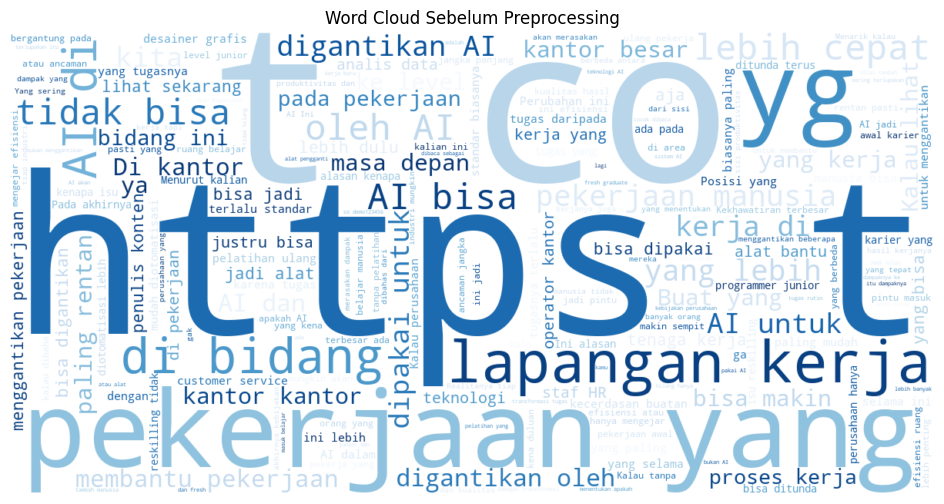

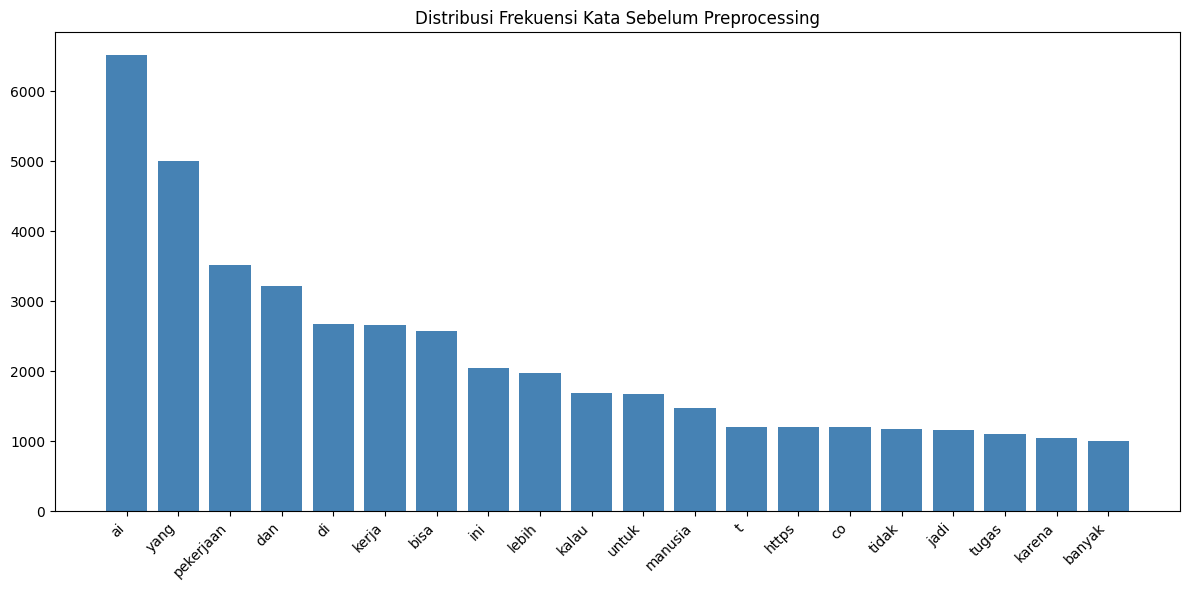

,kata,frekuensi
0,ai,6518
1,yang,5004
2,pekerjaan,3514
3,dan,3221
4,di,2673
5,kerja,2656
6,bisa,2571
7,ini,2053
8,lebih,1972
9,kalau,1688


In [5]:
# Menyiapkan teks sebelum preprocessing untuk visualisasi awal.

text_before = ' '.join(df['full_text'].dropna().astype(str))
tokens_before = re.findall(r'\b\w+\b', text_before.lower())
freq_before = pd.DataFrame(Counter(tokens_before).most_common(20), columns=['kata', 'frekuensi'])

if WORDCLOUD_AVAILABLE:
    plt.figure(figsize=(12, 6))
    wc = WordCloud(width=1200, height=600, background_color='white', colormap='Blues').generate(text_before)
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title('Word Cloud Sebelum Preprocessing')
    plt.show()
else:
    print('WordCloud belum terpasang. Visual word cloud dilewati sementara.')

plt.figure(figsize=(12, 6))
plt.bar(freq_before['kata'], freq_before['frekuensi'], color='steelblue')
plt.title('Distribusi Frekuensi Kata Sebelum Preprocessing')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

freq_before

## 4.4 Case Folding

Case folding dilakukan dengan mengubah seluruh huruf pada teks menjadi huruf kecil. Langkah ini berguna untuk menyamakan bentuk kata sehingga model tidak menganggap kata yang sama sebagai token yang berbeda hanya karena perbedaan kapital.


In [6]:
# Mengubah seluruh teks menjadi huruf kecil.
# Hasil tahap ini disimpan pada kolom text_casefold.

df['text_casefold'] = df['full_text'].astype(str).str.lower()

display(df[['full_text', 'text_casefold']].head(10))

,full_text,text_casefold
0,@DesWira15 @FaGtng Hilirisasi digital adalah strategi untuk mengolah bahan baku digital seperti data menjadi produk bernilai tinggi mirip hilirisasi industri. Contoh: bangun data center kembangkan...,@deswira15 @fagtng hilirisasi digital adalah strategi untuk mengolah bahan baku digital seperti data menjadi produk bernilai tinggi mirip hilirisasi industri. contoh: bangun data center kembangkan...
1,@FaGtng SMA SAJA TIDAK LULUS KERJA DICARIKAN ORANG TUA DAN PAMANNYA .... PAKAI NGOMONG TENTANG AI HILIRISASI DIGITAL DAN MENCIPTAKAN LAPANGAN KERJA .... DASAR KELUARGA PENIPU ....,@fagtng sma saja tidak lulus kerja dicarikan orang tua dan pamannya .... pakai ngomong tentang ai hilirisasi digital dan menciptakan lapangan kerja .... dasar keluarga penipu ....
2,gausah marah atau nganggap gue arogan atau apapun nyatanya yang tergantikan AI katanya itu ya karna emang mereka ga punya skill ga ada AI pun belom tentu bisa bersaing ditengah lapangan kerja yang...,gausah marah atau nganggap gue arogan atau apapun nyatanya yang tergantikan ai katanya itu ya karna emang mereka ga punya skill ga ada ai pun belom tentu bisa bersaing ditengah lapangan kerja yang...
3,@Duren___ @NgkongRoses Padahal ai dan codinglah yang akan membuat lapangan kerja mengecil?,@duren___ @ngkongroses padahal ai dan codinglah yang akan membuat lapangan kerja mengecil?
4,@Ary_PrasKe2 Bu guru rupanya gak paham apa yg dikatakan mas wapres. AI dan Coding adalah wujud dari 19 jta lapangan kerja yg dijanjikan AI dan Coding diperuntukan bagi pengangguran sebagai ganti p...,@ary_praske2 bu guru rupanya gak paham apa yg dikatakan mas wapres. ai dan coding adalah wujud dari 19 jta lapangan kerja yg dijanjikan ai dan coding diperuntukan bagi pengangguran sebagai ganti p...
5,Wapres muda dan visioner. 19 jt lapangan kerja pasti terwujud stlh 12 thn. Semua hrs bertahap. Dimulai dari pendidikan AI dan coding sejak SD. Otomatis stlh 12 thn 19 bahkan 190 juta lapangan kerj...,wapres muda dan visioner. 19 jt lapangan kerja pasti terwujud stlh 12 thn. semua hrs bertahap. dimulai dari pendidikan ai dan coding sejak sd. otomatis stlh 12 thn 19 bahkan 190 juta lapangan kerj...
6,@WagimanDeep212_ Ternyata 19 juta lapangan kerja yg dijanjikan baru akan tercipta 12 thn kedepan. Dimulai dari pendidikan AI dan coding sejak SD. Untuk saat ini Gibran blm dpt membuat 19 juta lapa...,@wagimandeep212_ ternyata 19 juta lapangan kerja yg dijanjikan baru akan tercipta 12 thn kedepan. dimulai dari pendidikan ai dan coding sejak sd. untuk saat ini gibran blm dpt membuat 19 juta lapa...
7,@WagimanDeep212_ Presidennya konsen pada pendidikan eh wakilnya nggak nyambung pendidikannya makanya ditanya 19jt lapangan kerja malah jawab penguasaan AI dan coding bener bener fufufafa nih wapre...,@wagimandeep212_ presidennya konsen pada pendidikan eh wakilnya nggak nyambung pendidikannya makanya ditanya 19jt lapangan kerja malah jawab penguasaan ai dan coding bener bener fufufafa nih wapre...
8,@ykuarina Terus hubungannya lapangan kerja sama AI dan Coding apa anjrit itu kan yang pada nganggur udah pada selesai sekolah semua,@ykuarina terus hubungannya lapangan kerja sama ai dan coding apa anjrit itu kan yang pada nganggur udah pada selesai sekolah semua
9,@__AnakKolong Mereka pemilihmu pak @prabowo bantulah pulihkan keadaan mereka dan bukakan lapangan kerja untuk mereka. Jangan lupa wapres muda yang cerdas juga wajib bertanggung jawab @gibran_tweet...,@__anakkolong mereka pemilihmu pak @prabowo bantulah pulihkan keadaan mereka dan bukakan lapangan kerja untuk mereka. jangan lupa wapres muda yang cerdas juga wajib bertanggung jawab @gibran_tweet...


## 4.5 Normalization

Tahap normalisasi dilakukan untuk membersihkan unsur-unsur yang tidak diperlukan dalam teks, seperti URL, mention, hashtag, dan simbol HTML. Pada penelitian ini, normalisasi juga dibedakan menjadi dua jalur, yaitu normalisasi ringan untuk model transformer dan normalisasi yang ditambah penyetaraan beberapa kata tidak baku untuk model baseline.

Dengan cara ini, kebutuhan preprocessing pada `TF-IDF + SVM` dan pada model transformer tetap dapat dipisahkan dengan lebih jelas.

In [7]:
# Normalisasi teks dilakukan setelah case folding.
# Di satu tahap ini, kita siapkan dua versi teks:
# 1. text_light_normalized untuk model transformer
# 2. text_normalized untuk baseline setelah beberapa kata tidak baku disetarakan

URL_PATTERN = re.compile(r'https?://\S+|www\.\S+')
MENTION_PATTERN = re.compile(r'@\w+')
HASHTAG_PATTERN = re.compile(r'#(\w+)')
NON_ALNUM_PATTERN = re.compile(r'[^a-z0-9\s]')
MULTISPACE_PATTERN = re.compile(r'\s+')

SLANG_MAP = {
    'yg': 'yang', 'ga': 'tidak', 'gak': 'tidak', 'nggak': 'tidak', 'tdk': 'tidak',
    'krn': 'karena', 'dr': 'dari', 'utk': 'untuk', 'dgn': 'dengan', 'aja': 'saja',
    'udah': 'sudah', 'blm': 'belum', 'bgt': 'banget', 'jd': 'jadi', 'org': 'orang',
    'hrs': 'harus', 'thn': 'tahun', 'dpt': 'dapat'
}

def light_normalize_text(text):
    text = str(text)
    text = text.replace('&amp', ' dan ')
    text = text.replace('&lt', ' ')
    text = text.replace('&gt', ' ')
    text = URL_PATTERN.sub(' ', text)
    text = MENTION_PATTERN.sub(' ', text)
    text = HASHTAG_PATTERN.sub(r'\1', text)
    text = NON_ALNUM_PATTERN.sub(' ', text)
    text = MULTISPACE_PATTERN.sub(' ', text).strip()
    return text

def normalize_slang_words(text):
    tokens = str(text).split()
    normalized_tokens = [SLANG_MAP.get(token, token) for token in tokens]
    return ' '.join(normalized_tokens)

df['text_light_normalized'] = df['text_casefold'].apply(light_normalize_text)
df['text_normalized'] = df['text_light_normalized'].apply(normalize_slang_words)

display(df[['text_light_normalized', 'text_normalized']].head(10))

,text_light_normalized,text_normalized
0,hilirisasi digital adalah strategi untuk mengolah bahan baku digital seperti data menjadi produk bernilai tinggi mirip hilirisasi industri contoh bangun data center kembangkan ai dan blockchain un...,hilirisasi digital adalah strategi untuk mengolah bahan baku digital seperti data menjadi produk bernilai tinggi mirip hilirisasi industri contoh bangun data center kembangkan ai dan blockchain un...
1,sma saja tidak lulus kerja dicarikan orang tua dan pamannya pakai ngomong tentang ai hilirisasi digital dan menciptakan lapangan kerja dasar keluarga penipu,sma saja tidak lulus kerja dicarikan orang tua dan pamannya pakai ngomong tentang ai hilirisasi digital dan menciptakan lapangan kerja dasar keluarga penipu
2,gausah marah atau nganggap gue arogan atau apapun nyatanya yang tergantikan ai katanya itu ya karna emang mereka ga punya skill ga ada ai pun belom tentu bisa bersaing ditengah lapangan kerja yang...,gausah marah atau nganggap gue arogan atau apapun nyatanya yang tergantikan ai katanya itu ya karna emang mereka tidak punya skill tidak ada ai pun belom tentu bisa bersaing ditengah lapangan kerj...
3,padahal ai dan codinglah yang akan membuat lapangan kerja mengecil,padahal ai dan codinglah yang akan membuat lapangan kerja mengecil
4,bu guru rupanya gak paham apa yg dikatakan mas wapres ai dan coding adalah wujud dari 19 jta lapangan kerja yg dijanjikan ai dan coding diperuntukan bagi pengangguran sebagai ganti pekerjaan formal,bu guru rupanya tidak paham apa yang dikatakan mas wapres ai dan coding adalah wujud dari 19 jta lapangan kerja yang dijanjikan ai dan coding diperuntukan bagi pengangguran sebagai ganti pekerjaan...
5,wapres muda dan visioner 19 jt lapangan kerja pasti terwujud stlh 12 thn semua hrs bertahap dimulai dari pendidikan ai dan coding sejak sd otomatis stlh 12 thn 19 bahkan 190 juta lapangan kerja te...,wapres muda dan visioner 19 jt lapangan kerja pasti terwujud stlh 12 tahun semua harus bertahap dimulai dari pendidikan ai dan coding sejak sd otomatis stlh 12 tahun 19 bahkan 190 juta lapangan ke...
6,ternyata 19 juta lapangan kerja yg dijanjikan baru akan tercipta 12 thn kedepan dimulai dari pendidikan ai dan coding sejak sd untuk saat ini gibran blm dpt membuat 19 juta lapangan kerja krn pend...,ternyata 19 juta lapangan kerja yang dijanjikan baru akan tercipta 12 tahun kedepan dimulai dari pendidikan ai dan coding sejak sd untuk saat ini gibran belum dapat membuat 19 juta lapangan kerja ...
7,presidennya konsen pada pendidikan eh wakilnya nggak nyambung pendidikannya makanya ditanya 19jt lapangan kerja malah jawab penguasaan ai dan coding bener bener fufufafa nih wapres lagian yang nan...,presidennya konsen pada pendidikan eh wakilnya tidak nyambung pendidikannya makanya ditanya 19jt lapangan kerja malah jawab penguasaan ai dan coding bener bener fufufafa nih wapres lagian yang nan...
8,terus hubungannya lapangan kerja sama ai dan coding apa anjrit itu kan yang pada nganggur udah pada selesai sekolah semua,terus hubungannya lapangan kerja sama ai dan coding apa anjrit itu kan yang pada nganggur sudah pada selesai sekolah semua
9,mereka pemilihmu pak bantulah pulihkan keadaan mereka dan bukakan lapangan kerja untuk mereka jangan lupa wapres muda yang cerdas juga wajib bertanggung jawab jangan hanya bisa ngomong soal ai sam...,mereka pemilihmu pak bantulah pulihkan keadaan mereka dan bukakan lapangan kerja untuk mereka jangan lupa wapres muda yang cerdas juga wajib bertanggung jawab jangan hanya bisa ngomong soal ai sam...


## 4.6 Stopword Removal

Setelah teks dinormalisasi, tahap berikutnya adalah menghapus stopword atau kata-kata umum yang terlalu sering muncul tetapi tidak banyak membantu proses klasifikasi. Contohnya adalah kata seperti `yang`, `dan`, `di`, atau `ke`.

Pada penelitian ini, stopword removal dimasukkan khusus untuk jalur baseline `TF-IDF + SVM` agar kata yang dipertahankan lebih fokus pada isi utama tweet.

In [8]:
# Stopword removal dilakukan setelah normalisasi.
# Beberapa kata penting tetap dipertahankan karena masih membantu
# membedakan makna kalimat pada proses klasifikasi.

DEFAULT_STOPWORDS = {
    'yang', 'dan', 'di', 'ke', 'dari', 'untuk', 'pada', 'dengan', 'dalam',
    'atau', 'juga', 'karena', 'agar', 'sebagai', 'adalah', 'itu', 'ini',
    'sudah', 'telah', 'akan', 'lebih', 'saja', 'jadi', 'masih', 'para',
    'oleh', 'seperti', 'dapat', 'bisa', 'buat', 'bagi', 'secara', 'nya',
    'si', 'kok', 'nih', 'deh', 'dong', 'ya', 'yg', 'ga', 'gak'
}

KEEP_WORDS = {'tidak', 'bukan', 'belum', 'tanpa', 'kurang'}

try:
    from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
    stopwords_id = set(StopWordRemoverFactory().get_stop_words())
    stopword_source = 'Sastrawi'
except ImportError:
    stopwords_id = set(DEFAULT_STOPWORDS)
    stopword_source = 'daftar stopword bawaan notebook'

stopwords_id = stopwords_id - KEEP_WORDS

def remove_stopwords(text):
    tokens = str(text).split()
    filtered_tokens = [token for token in tokens if token not in stopwords_id]
    return ' '.join(filtered_tokens)

df['text_stopword_removed'] = df['text_normalized'].apply(remove_stopwords)

print('Sumber stopword:', stopword_source)
display(df[['text_normalized', 'text_stopword_removed']].head(10))

Sumber stopword: Sastrawi


,text_normalized,text_stopword_removed
0,hilirisasi digital adalah strategi untuk mengolah bahan baku digital seperti data menjadi produk bernilai tinggi mirip hilirisasi industri contoh bangun data center kembangkan ai dan blockchain un...,hilirisasi digital strategi mengolah bahan baku digital data menjadi produk bernilai tinggi mirip hilirisasi industri contoh bangun data center kembangkan ai blockchain ciptakan lapangan kerja tingka
1,sma saja tidak lulus kerja dicarikan orang tua dan pamannya pakai ngomong tentang ai hilirisasi digital dan menciptakan lapangan kerja dasar keluarga penipu,sma tidak lulus kerja dicarikan orang tua pamannya pakai ngomong ai hilirisasi digital menciptakan lapangan kerja dasar keluarga penipu
2,gausah marah atau nganggap gue arogan atau apapun nyatanya yang tergantikan ai katanya itu ya karna emang mereka tidak punya skill tidak ada ai pun belom tentu bisa bersaing ditengah lapangan kerj...,gausah marah nganggap gue arogan apapun nyatanya tergantikan ai katanya karna emang tidak punya skill tidak ai belom bersaing ditengah lapangan kerja sedikit orang orang terus berkembang tiap
3,padahal ai dan codinglah yang akan membuat lapangan kerja mengecil,padahal ai codinglah membuat lapangan kerja mengecil
4,bu guru rupanya tidak paham apa yang dikatakan mas wapres ai dan coding adalah wujud dari 19 jta lapangan kerja yang dijanjikan ai dan coding diperuntukan bagi pengangguran sebagai ganti pekerjaan...,bu guru rupanya tidak paham apa dikatakan mas wapres ai coding wujud 19 jta lapangan kerja dijanjikan ai coding diperuntukan pengangguran ganti pekerjaan formal
5,wapres muda dan visioner 19 jt lapangan kerja pasti terwujud stlh 12 tahun semua harus bertahap dimulai dari pendidikan ai dan coding sejak sd otomatis stlh 12 tahun 19 bahkan 190 juta lapangan ke...,wapres muda visioner 19 jt lapangan kerja terwujud stlh 12 tahun semua bertahap dimulai pendidikan ai coding sejak sd otomatis stlh 12 tahun 19 bahkan 190 juta lapangan kerja tercipta berkat ai co...
6,ternyata 19 juta lapangan kerja yang dijanjikan baru akan tercipta 12 tahun kedepan dimulai dari pendidikan ai dan coding sejak sd untuk saat ini gibran belum dapat membuat 19 juta lapangan kerja ...,ternyata 19 juta lapangan kerja dijanjikan baru tercipta 12 tahun kedepan dimulai pendidikan ai coding sejak sd gibran belum membuat 19 juta lapangan kerja pendidikan ai coding baru dimulai
7,presidennya konsen pada pendidikan eh wakilnya tidak nyambung pendidikannya makanya ditanya 19jt lapangan kerja malah jawab penguasaan ai dan coding bener bener fufufafa nih wapres lagian yang nan...,presidennya konsen pendidikan eh wakilnya tidak nyambung pendidikannya makanya ditanya 19jt lapangan kerja malah jawab penguasaan ai coding bener bener fufufafa nih wapres lagian nanya nya kok soa...
8,terus hubungannya lapangan kerja sama ai dan coding apa anjrit itu kan yang pada nganggur sudah pada selesai sekolah semua,terus hubungannya lapangan kerja sama ai coding apa anjrit kan nganggur selesai sekolah semua
9,mereka pemilihmu pak bantulah pulihkan keadaan mereka dan bukakan lapangan kerja untuk mereka jangan lupa wapres muda yang cerdas juga wajib bertanggung jawab jangan hanya bisa ngomong soal ai sam...,pemilihmu pak bantulah pulihkan keadaan bukakan lapangan kerja jangan lupa wapres muda cerdas wajib bertanggung jawab jangan ngomong soal ai sama coding doang g


## 4.7 Catatan Tokenisasi pada TF-IDF

Pada model baseline `TF-IDF + SVM`, tokenisasi tidak dilakukan secara manual. Hal ini karena `TfidfVectorizer` dari scikit-learn sudah melakukan tokenisasi secara otomatis saat teks diubah menjadi fitur numerik.

Dengan demikian, pada implementasi baseline ini, teks hasil stopword removal dapat langsung dipakai sebagai masukan untuk TF-IDF tanpa perlu membuat token satu per satu secara manual.

In [9]:
# Pada baseline TF-IDF, tokenisasi ditangani otomatis oleh TfidfVectorizer.
# Karena itu, teks hasil stopword removal disiapkan langsung
# sebagai skenario tanpa stemming.

df['text_no_stemming'] = df['text_stopword_removed']

display(df[['text_stopword_removed', 'text_no_stemming']].head(10))

,text_stopword_removed,text_no_stemming
0,hilirisasi digital strategi mengolah bahan baku digital data menjadi produk bernilai tinggi mirip hilirisasi industri contoh bangun data center kembangkan ai blockchain ciptakan lapangan kerja tingka,hilirisasi digital strategi mengolah bahan baku digital data menjadi produk bernilai tinggi mirip hilirisasi industri contoh bangun data center kembangkan ai blockchain ciptakan lapangan kerja tingka
1,sma tidak lulus kerja dicarikan orang tua pamannya pakai ngomong ai hilirisasi digital menciptakan lapangan kerja dasar keluarga penipu,sma tidak lulus kerja dicarikan orang tua pamannya pakai ngomong ai hilirisasi digital menciptakan lapangan kerja dasar keluarga penipu
2,gausah marah nganggap gue arogan apapun nyatanya tergantikan ai katanya karna emang tidak punya skill tidak ai belom bersaing ditengah lapangan kerja sedikit orang orang terus berkembang tiap,gausah marah nganggap gue arogan apapun nyatanya tergantikan ai katanya karna emang tidak punya skill tidak ai belom bersaing ditengah lapangan kerja sedikit orang orang terus berkembang tiap
3,padahal ai codinglah membuat lapangan kerja mengecil,padahal ai codinglah membuat lapangan kerja mengecil
4,bu guru rupanya tidak paham apa dikatakan mas wapres ai coding wujud 19 jta lapangan kerja dijanjikan ai coding diperuntukan pengangguran ganti pekerjaan formal,bu guru rupanya tidak paham apa dikatakan mas wapres ai coding wujud 19 jta lapangan kerja dijanjikan ai coding diperuntukan pengangguran ganti pekerjaan formal
5,wapres muda visioner 19 jt lapangan kerja terwujud stlh 12 tahun semua bertahap dimulai pendidikan ai coding sejak sd otomatis stlh 12 tahun 19 bahkan 190 juta lapangan kerja tercipta berkat ai co...,wapres muda visioner 19 jt lapangan kerja terwujud stlh 12 tahun semua bertahap dimulai pendidikan ai coding sejak sd otomatis stlh 12 tahun 19 bahkan 190 juta lapangan kerja tercipta berkat ai co...
6,ternyata 19 juta lapangan kerja dijanjikan baru tercipta 12 tahun kedepan dimulai pendidikan ai coding sejak sd gibran belum membuat 19 juta lapangan kerja pendidikan ai coding baru dimulai,ternyata 19 juta lapangan kerja dijanjikan baru tercipta 12 tahun kedepan dimulai pendidikan ai coding sejak sd gibran belum membuat 19 juta lapangan kerja pendidikan ai coding baru dimulai
7,presidennya konsen pendidikan eh wakilnya tidak nyambung pendidikannya makanya ditanya 19jt lapangan kerja malah jawab penguasaan ai coding bener bener fufufafa nih wapres lagian nanya nya kok soa...,presidennya konsen pendidikan eh wakilnya tidak nyambung pendidikannya makanya ditanya 19jt lapangan kerja malah jawab penguasaan ai coding bener bener fufufafa nih wapres lagian nanya nya kok soa...
8,terus hubungannya lapangan kerja sama ai coding apa anjrit kan nganggur selesai sekolah semua,terus hubungannya lapangan kerja sama ai coding apa anjrit kan nganggur selesai sekolah semua
9,pemilihmu pak bantulah pulihkan keadaan bukakan lapangan kerja jangan lupa wapres muda cerdas wajib bertanggung jawab jangan ngomong soal ai sama coding doang g,pemilihmu pak bantulah pulihkan keadaan bukakan lapangan kerja jangan lupa wapres muda cerdas wajib bertanggung jawab jangan ngomong soal ai sama coding doang g


## 4.8 Stemming

Stemming dilakukan untuk mengubah kata berimbuhan menjadi bentuk dasar. Pada bahasa Indonesia, proses ini dapat membantu menyatukan variasi kata yang maknanya sama agar fitur yang dipakai model menjadi lebih konsisten.

Pada notebook ini, stemming tetap diuji sebagai salah satu variasi eksperimen baseline. Dengan begitu, hasil model setelah stopword removal tanpa stemming dan sesudah stemming dapat dibandingkan secara langsung.

In [10]:
# Tahap stemming menggunakan Sastrawi.

try:
    from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
    stemmer = StemmerFactory().create_stemmer()
    df['text_stemmed'] = df['text_stopword_removed'].apply(stemmer.stem)
except ImportError:
    print('Sastrawi belum terpasang. Teks tanpa stemming dipakai sementara.')
    df['text_stemmed'] = df['text_stopword_removed']

display(df[['text_stopword_removed', 'text_stemmed']].head(10))

,text_stopword_removed,text_stemmed
0,hilirisasi digital strategi mengolah bahan baku digital data menjadi produk bernilai tinggi mirip hilirisasi industri contoh bangun data center kembangkan ai blockchain ciptakan lapangan kerja tingka,hilir digital strategi olah bahan baku digital data jadi produk nila tinggi mirip hilir industri contoh bangun data center kembang ai blockchain cipta lapang kerja tingka
1,sma tidak lulus kerja dicarikan orang tua pamannya pakai ngomong ai hilirisasi digital menciptakan lapangan kerja dasar keluarga penipu,sma tidak lulus kerja cari orang tua paman pakai ngomong ai hilir digital cipta lapang kerja dasar keluarga tipu
2,gausah marah nganggap gue arogan apapun nyatanya tergantikan ai katanya karna emang tidak punya skill tidak ai belom bersaing ditengah lapangan kerja sedikit orang orang terus berkembang tiap,gausah marah nganggap gue arogan apa nyata ganti ai kata karna emang tidak punya skill tidak ai bom saing tengah lapang kerja sedikit orang orang terus kembang tiap
3,padahal ai codinglah membuat lapangan kerja mengecil,padahal ai codinglah buat lapang kerja kecil
4,bu guru rupanya tidak paham apa dikatakan mas wapres ai coding wujud 19 jta lapangan kerja dijanjikan ai coding diperuntukan pengangguran ganti pekerjaan formal,bu guru rupa tidak paham apa kata mas wapres ai coding wujud 19 jta lapang kerja janji ai coding untuk anggur ganti kerja formal
5,wapres muda visioner 19 jt lapangan kerja terwujud stlh 12 tahun semua bertahap dimulai pendidikan ai coding sejak sd otomatis stlh 12 tahun 19 bahkan 190 juta lapangan kerja tercipta berkat ai co...,wapres muda visioner 19 jt lapang kerja wujud stlh 12 tahun semua tahap mulai didik ai coding sejak sd otomatis stlh 12 tahun 19 bahkan 190 juta lapang kerja cipta berkat ai coding untung rakyat p...
6,ternyata 19 juta lapangan kerja dijanjikan baru tercipta 12 tahun kedepan dimulai pendidikan ai coding sejak sd gibran belum membuat 19 juta lapangan kerja pendidikan ai coding baru dimulai,nyata 19 juta lapang kerja janji baru cipta 12 tahun depan mulai didik ai coding sejak sd gibran belum buat 19 juta lapang kerja didik ai coding baru mulai
7,presidennya konsen pendidikan eh wakilnya tidak nyambung pendidikannya makanya ditanya 19jt lapangan kerja malah jawab penguasaan ai coding bener bener fufufafa nih wapres lagian nanya nya kok soa...,presiden konsen didik eh wakil tidak nyambung didik makanya tanya 19jt lapang kerja malah jawab kuasa ai coding bener bener fufufafa nih wapres lagi nanya nya kok soal berat banget nya
8,terus hubungannya lapangan kerja sama ai coding apa anjrit kan nganggur selesai sekolah semua,terus hubung lapang kerja sama ai coding apa anjrit kan nganggur selesai sekolah semua
9,pemilihmu pak bantulah pulihkan keadaan bukakan lapangan kerja jangan lupa wapres muda cerdas wajib bertanggung jawab jangan ngomong soal ai sama coding doang g,pilih pak bantu pulih ada buka lapang kerja jangan lupa wapres muda cerdas wajib tanggung jawab jangan ngomong soal ai sama coding doang g


## 4.8.1 Visualisasi Data Setelah Preprocessing

Setelah preprocessing dilakukan, visualisasi kembali ditampilkan untuk melihat perubahan bentuk kata yang muncul pada dataset. Dengan cara ini, perbandingan sebelum dan sesudah preprocessing dapat diamati dengan lebih jelas.

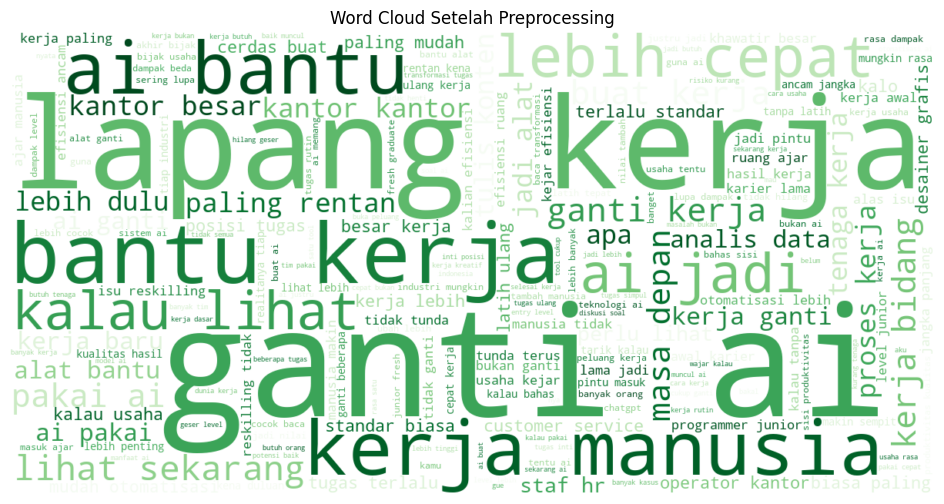

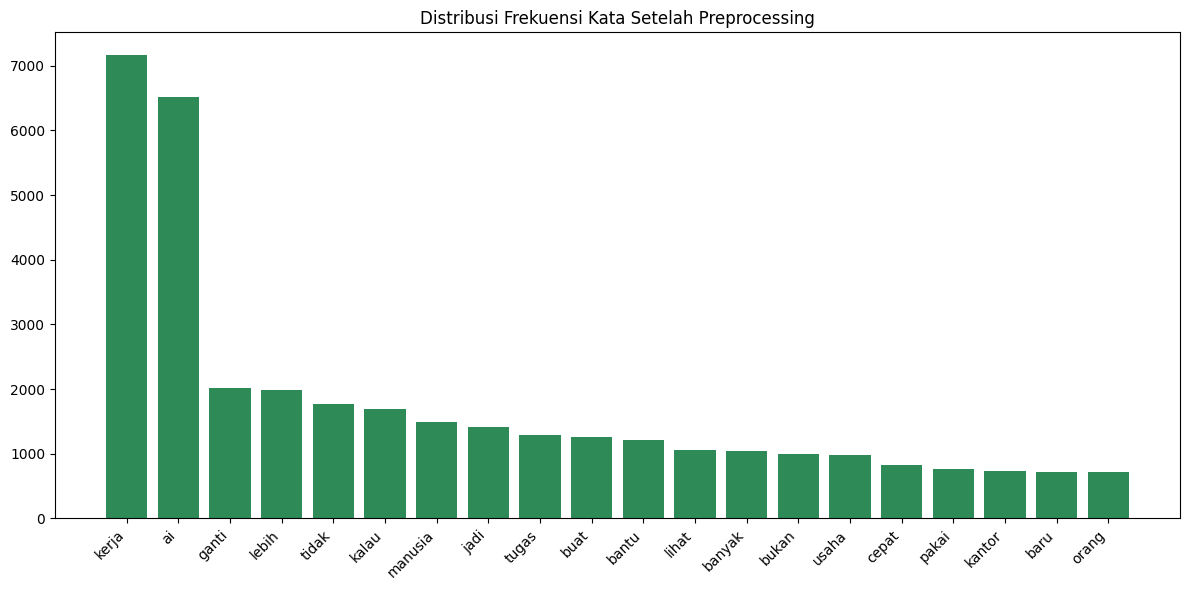

,kata,frekuensi
0,kerja,7159
1,ai,6518
2,ganti,2013
3,lebih,1983
4,tidak,1765
5,kalau,1688
6,manusia,1498
7,jadi,1410
8,tugas,1293
9,buat,1266


In [11]:
# Menyiapkan visualisasi setelah preprocessing.

text_after = ' '.join(df['text_stemmed'].dropna().astype(str))
tokens_after = re.findall(r'\b\w+\b', text_after.lower())
freq_after = pd.DataFrame(Counter(tokens_after).most_common(20), columns=['kata', 'frekuensi'])

if WORDCLOUD_AVAILABLE:
    plt.figure(figsize=(12, 6))
    wc = WordCloud(width=1200, height=600, background_color='white', colormap='Greens').generate(text_after)
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title('Word Cloud Setelah Preprocessing')
    plt.show()
else:
    print('WordCloud belum terpasang. Visual word cloud dilewati sementara.')

plt.figure(figsize=(12, 6))
plt.bar(freq_after['kata'], freq_after['frekuensi'], color='seagreen')
plt.title('Distribusi Frekuensi Kata Setelah Preprocessing')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

freq_after

## 4.9 Labeling

Setelah proses data cleansing dan preprocessing dasar disiapkan, tahap berikutnya adalah memastikan label klasifikasi yang digunakan sudah sesuai. Pada revisi setelah sidang, label manual tidak langsung dipakai sebagai label akhir, tetapi digunakan sebagai label awal dan dasar pembentukan data berlabel untuk proses semi-supervised labeling.

Pada tahap semi-supervised labeling, label tetap dibuat dalam tiga kategori:

- `ancaman`
- `peluang`
- `netral`

Kategori `netral` dipertahankan pada tahap semi-supervised sebagai kelas penyaring atau exclusion class. Tujuannya agar data yang tidak secara jelas menunjukkan narasi ancaman maupun peluang tidak dipaksa masuk ke salah satu kelas utama.

Setelah label final semi-supervised terbentuk, tahap pemodelan akhir difokuskan menjadi klasifikasi biner. Oleh karena itu, data berlabel `netral` dikeluarkan sebelum data splitting, sedangkan model hanya dilatih dan dievaluasi pada label `ancaman` dan `peluang`.

### 4.9.1 Validasi Pelabelan Menggunakan Cohen's Kappa

Sebelum label final digunakan pada tahap preprocessing dan pemodelan, kesepakatan antara dua annotator diperiksa menggunakan Cohen's Kappa. Perhitungan ini dilakukan pada file `Labeling Annotator Merged.csv` yang masih memuat label dari Annotator 1 dan Annotator 2.

Nilai Kappa digunakan untuk melihat seberapa konsisten kedua annotator memberi label setelah memperhitungkan kemungkinan kesamaan yang terjadi secara kebetulan. Setelah nilai kesepakatan dihitung, data yang berbeda label ditinjau untuk menentukan `Label Final`.


In [12]:
# Menghitung kesepakatan antar annotator menggunakan Cohen's Kappa.

from sklearn.metrics import cohen_kappa_score

labeling_path = Path('Labeling Annotator Merged.csv')
df_kappa = pd.read_csv(labeling_path, sep=';', encoding='utf-8-sig')

annotator_columns = ['Label_Annotator1', 'Label_Annotator2']

for column in annotator_columns:
    df_kappa[column] = df_kappa[column].astype(str).str.strip().str.lower()
    df_kappa.loc[df_kappa[column].isin(['', 'nan', 'none']), column] = pd.NA

df_kappa_valid = df_kappa.dropna(subset=annotator_columns).copy()

agreement_mask = (
    df_kappa_valid['Label_Annotator1']
    == df_kappa_valid['Label_Annotator2']
)

kappa_score = cohen_kappa_score(
    df_kappa_valid['Label_Annotator1'],
    df_kappa_valid['Label_Annotator2']
)

agreement_count = int(agreement_mask.sum())
disagreement_count = int((~agreement_mask).sum())
total_labeled = len(df_kappa_valid)
agreement_percentage = agreement_count / total_labeled * 100

kappa_summary = pd.DataFrame({
    'metrik': [
        'Jumlah data dibandingkan',
        'Jumlah agreement',
        'Jumlah disagreement',
        'Persentase agreement',
        "Cohen's Kappa"
    ],
    'nilai': [
        total_labeled,
        agreement_count,
        disagreement_count,
        f'{agreement_percentage:.2f}%',
        f'{kappa_score:.4f}'
    ]
})

print('Ringkasan validasi pelabelan:')
display(kappa_summary)

print('Matriks perbandingan label Annotator 1 dan Annotator 2:')
display(pd.crosstab(
    df_kappa_valid['Label_Annotator1'],
    df_kappa_valid['Label_Annotator2'],
    rownames=['Annotator 1'],
    colnames=['Annotator 2']
))

print('Contoh data disagreement:')
display(df_kappa_valid.loc[
    ~agreement_mask,
    ['full_text', 'Label_Annotator1', 'Label_Annotator2', 'Label Final']
].head(10))


Ringkasan validasi pelabelan:


,metrik,nilai
0,Jumlah data dibandingkan,1000
1,Jumlah agreement,933
2,Jumlah disagreement,67
3,Persentase agreement,93.30%
4,Cohen's Kappa,0.8906


Matriks perbandingan label Annotator 1 dan Annotator 2:


Annotator 2,ancaman,netral,peluang
Annotator 1,,,
ancaman,497,15,7
netral,9,178,16
peluang,12,8,258


Contoh data disagreement:


,full_text,Label_Annotator1,Label_Annotator2,Label Final
0,@DesWira15 @FaGtng Hilirisasi digital adalah strategi untuk mengolah bahan baku digital seperti data menjadi produk bernilai tinggi mirip hilirisasi industri. Contoh: bangun data center kembangkan...,netral,peluang,netral
1,@FaGtng SMA SAJA TIDAK LULUS KERJA DICARIKAN ORANG TUA DAN PAMANNYA .... PAKAI NGOMONG TENTANG AI HILIRISASI DIGITAL DAN MENCIPTAKAN LAPANGAN KERJA .... DASAR KELUARGA PENIPU ....,netral,ancaman,netral
4,@Ary_PrasKe2 Bu guru rupanya gak paham apa yg dikatakan mas wapres. AI dan Coding adalah wujud dari 19 jta lapangan kerja yg dijanjikan AI dan Coding diperuntukan bagi pengangguran sebagai ganti p...,peluang,ancaman,peluang
8,@ykuarina Terus hubungannya lapangan kerja sama AI dan Coding apa anjrit itu kan yang pada nganggur udah pada selesai sekolah semua,netral,ancaman,netral
10,@Terserahdeh97 Hai Pengangguran... Pemerintah sudah menyediakan 19 juta lapangan kerja Belajar Coding dan AI. Solusi Cerdas untuk menahan perut LAPAR,peluang,netral,peluang
13,@WagimanDeep212_ Ini Gibran goblok apa cerdas yang ditanya terkait urgentinya lapangan kerja jawabannya AI dan coding Kalo coding itu robotik karena semua dimonopoli mesin sementara yg dibutuhkan ...,ancaman,netral,ancaman
14,Janji penciptaan 19 juta lapangan kerja kembali menjadi sorotan setelah BPS mencatat pengangguran mencapai 7 46 juta orang per Agustus 2025. Gibran menegaskan pemerintah menyiapkan SDM dan fasilit...,peluang,ancaman,peluang
15,@Zeefire02 Gak nyambung tanya lapangan kerja jawab coding dan AI. Lu kira om-om umur 30an perlu belajar coding dan AI juga?,netral,peluang,netral
17,@KangManto123 Di mana tanya 19 jt lapangan kerja berarti emang org butuh kerja buat dpt duit kalo belajar ai coding berarti msh belajar di bangku sekolah dan msh minta duit sama ortu,netral,peluang,netral
18,Kapan dia pernah jawab pertanyaan tentang lapangan kerja tanpa ada unsur ai dan coding di jawabannya,netral,peluang,netral


In [13]:
# Menyiapkan label manual awal sebagai referensi sebelum semi-supervised labeling.

# Label pada tahap semi-supervised tetap tiga kelas.
# Label netral dipakai sebagai kelas penyaring agar data yang tidak jelas
# tidak dipaksa menjadi ancaman atau peluang.
SEMI_SUPERVISED_LABELS = ['ancaman', 'peluang', 'netral']

# Label pada tahap modeling akhir dibuat biner.
MODEL_LABELS = ['ancaman', 'peluang']

VALID_LABELS = SEMI_SUPERVISED_LABELS

df['label_manual_awal'] = df['manual_labeling'].astype(str).str.strip().str.lower()
df.loc[df['label_manual_awal'].isin(['', 'nan', 'none']), 'label_manual_awal'] = np.nan

# Sementara, label_final masih mengikuti label manual awal.
# Pada tahap semi-supervised berikutnya, kolom ini akan diganti dengan
# label_final_semisupervised agar seluruh model di bawahnya memakai label revisi.
df['label_final'] = df['label_manual_awal']

print('Distribusi label manual awal:')
display(df['label_manual_awal'].value_counts(dropna=False))

Distribusi label manual awal:


label_manual_awal
netral     1943
ancaman    1782
peluang    1501
Name: count, dtype: int64

### 4.9.2 Semi-Supervised Labeling dengan Seed 300 Clear

Tahap ini menggunakan 300 data seed yang dipilih sebagai contoh paling jelas untuk tiap kategori, yaitu 100 data `ancaman`, 100 data `peluang`, dan 100 data `netral`. File seed yang digunakan adalah `semi_supervised_seed_300_clear.csv`.

Meskipun tahap modeling akhir dibuat biner, seed semi-supervised tidak diubah menjadi 200 data. Kelas `netral` tetap dipertahankan pada tahap labeling karena berfungsi sebagai kelas penyaring. Tanpa kelas `netral`, data yang bersifat informatif atau ambigu akan dipaksa masuk ke `ancaman` atau `peluang`, sehingga berisiko menambah noise pada label akhir.

Pada notebook revisi ini, skema semi-supervised difokuskan pada satu pendekatan yang paling stabil dari eksperimen sebelumnya:

- input teks: `text_no_stemming` atau teks hasil normalisasi dan stopword removal tanpa stemming;
- fitur: `TF-IDF` unigram-bigram;
- model: `Logistic Regression` di dalam `SelfTrainingClassifier`;
- threshold penerimaan pseudo-label: `0.75`.

Data 1000 annotator tetap digunakan pada bagian 4.9.1 untuk validasi reliabilitas pelabelan dengan Cohen's Kappa, tetapi tidak lagi digunakan sebagai seed semi-supervised pada alur utama notebook ini.

In [14]:
# Menyiapkan seed 300 clear sebagai data berlabel awal semi-supervised.

from sklearn.linear_model import LogisticRegression
from sklearn.semi_supervised import SelfTrainingClassifier

RANDOM_STATE = 42
CONFIDENCE_THRESHOLD = 0.75
TEXT_COLUMN_SEMISUPERVISED = 'text_no_stemming'
SEED_300_CLEAR_PATH = Path('semi_supervised_seed_300_clear.csv')

if not SEED_300_CLEAR_PATH.exists():
    raise FileNotFoundError(f'File seed tidak ditemukan: {SEED_300_CLEAR_PATH}')

df_seed = pd.read_csv(SEED_300_CLEAR_PATH, sep=';', encoding='utf-8-sig')

required_seed_columns = {'full_text', 'seed_label'}
missing_seed_columns = required_seed_columns - set(df_seed.columns)
if missing_seed_columns:
    raise ValueError(f'Kolom seed belum lengkap: {sorted(missing_seed_columns)}')

def normalize_matching_key(text):
    return re.sub(r'\s+', ' ', str(text)).strip()

# Key dipakai agar seed 300 bisa dicocokkan kembali dengan Dataset Final.csv.
df['semi_text_key'] = df['full_text'].apply(normalize_matching_key)
df_seed['semi_text_key'] = df_seed['full_text'].apply(normalize_matching_key)

df_seed['seed_label'] = df_seed['seed_label'].astype(str).str.strip().str.lower()
df_seed = df_seed[df_seed['seed_label'].isin(VALID_LABELS)].copy()
df_seed_unique = df_seed.drop_duplicates(subset=['semi_text_key']).copy()

seed_label_map = df_seed_unique.set_index('semi_text_key')['seed_label']
df['seed_label'] = df['semi_text_key'].map(seed_label_map)
df['is_seed_label'] = df['seed_label'].isin(VALID_LABELS)

seed_summary = pd.DataFrame({
    'metrik': [
        'Jumlah seed 300 clear',
        'Jumlah seed 300 clear unik',
        'Jumlah seed yang cocok dengan Dataset Final',
        'Jumlah data non-seed / diperlakukan unlabeled'
    ],
    'nilai': [
        len(df_seed),
        len(df_seed_unique),
        int(df['is_seed_label'].sum()),
        int((~df['is_seed_label']).sum())
    ]
})

print('Ringkasan seed semi-supervised:')
display(seed_summary)

print('Distribusi label seed 300 clear:')
display(df.loc[df['is_seed_label'], 'seed_label'].value_counts().reindex(VALID_LABELS).fillna(0).astype(int))

Ringkasan seed semi-supervised:


,metrik,nilai
0,Jumlah seed 300 clear,300
1,Jumlah seed 300 clear unik,300
2,Jumlah seed yang cocok dengan Dataset Final,300
3,Jumlah data non-seed / diperlakukan unlabeled,4926


Distribusi label seed 300 clear:


seed_label
ancaman    100
peluang    100
netral     100
Name: count, dtype: int64

In [15]:
# Melatih model semi-supervised dan membentuk label final.

# Semi-supervised tetap memakai tiga kelas, termasuk netral sebagai kelas penyaring.
label2id_semi = {label: idx for idx, label in enumerate(SEMI_SUPERVISED_LABELS)}
id2label_semi = {v: k for k, v in label2id_semi.items()}

seed_mask = df['is_seed_label'] & df['seed_label'].isin(VALID_LABELS)
pseudo_mask = ~seed_mask

semi_tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True
)

X_semi = semi_tfidf.fit_transform(df[TEXT_COLUMN_SEMISUPERVISED].fillna('').astype(str))
y_semi = np.full(len(df), -1, dtype=int)
y_semi[seed_mask.to_numpy()] = (
    df.loc[seed_mask, 'seed_label']
    .map(label2id_semi)
    .astype(int)
    .to_numpy()
)

base_logreg = LogisticRegression(
    max_iter=2000,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    solver='lbfgs'
)

def build_self_training_classifier(base_estimator, threshold):
    try:
        return SelfTrainingClassifier(
            estimator=base_estimator,
            threshold=threshold,
            criterion='threshold',
            max_iter=10,
            verbose=True
        )
    except TypeError:
        # Kompatibilitas untuk scikit-learn versi lama yang masih memakai base_estimator.
        return SelfTrainingClassifier(
            base_estimator=base_estimator,
            threshold=threshold,
            criterion='threshold',
            max_iter=10,
            verbose=True
        )

semi_supervised_model = build_self_training_classifier(base_logreg, CONFIDENCE_THRESHOLD)
semi_supervised_model.fit(X_semi, y_semi)

semi_pred_id = semi_supervised_model.predict(X_semi)
semi_proba = semi_supervised_model.predict_proba(X_semi)
semi_confidence = pd.Series(semi_proba.max(axis=1), index=df.index)
semi_pred_label = pd.Series([id2label_semi[int(label_id)] for label_id in semi_pred_id], index=df.index)

df['semi_supervised_label'] = semi_pred_label
df['semi_supervised_confidence'] = semi_confidence

# Data seed tetap mengikuti label manual yang dipilih sebagai seed.
df.loc[seed_mask, 'semi_supervised_label'] = df.loc[seed_mask, 'seed_label']

high_confidence_mask = pseudo_mask & (df['semi_supervised_confidence'] >= CONFIDENCE_THRESHOLD)
low_confidence_mask = pseudo_mask & (df['semi_supervised_confidence'] < CONFIDENCE_THRESHOLD)
manual_reference_mask = df['label_manual_awal'].isin(VALID_LABELS)
diff_from_manual_mask = (
    pseudo_mask
    & manual_reference_mask
    & (df['semi_supervised_label'] != df['label_manual_awal'])
)

df['label_decision_semisupervised'] = 'pseudo_label_high_confidence'
df.loc[seed_mask, 'label_decision_semisupervised'] = 'manual_seed_300'
df.loc[high_confidence_mask & diff_from_manual_mask, 'label_decision_semisupervised'] = (
    'pseudo_high_confidence_differs_from_manual_reference'
)
df.loc[low_confidence_mask & manual_reference_mask, 'label_decision_semisupervised'] = (
    'review_low_confidence_use_manual_reference'
)
df.loc[low_confidence_mask & ~manual_reference_mask, 'label_decision_semisupervised'] = (
    'review_low_confidence_no_manual_reference'
)

df['needs_manual_review'] = low_confidence_mask
df['differs_from_manual_awal'] = diff_from_manual_mask

# Label final untuk pemodelan:
# - seed memakai label seed 300;
# - pseudo-label confidence tinggi diterima sebagai label semi-supervised;
# - pseudo-label confidence rendah memakai label manual awal sebagai fallback sementara.
fallback_label = df['label_manual_awal'].where(manual_reference_mask, df['semi_supervised_label'])
df['label_final_semisupervised'] = df['semi_supervised_label']
df.loc[seed_mask, 'label_final_semisupervised'] = df.loc[seed_mask, 'seed_label']
df.loc[low_confidence_mask, 'label_final_semisupervised'] = fallback_label[low_confidence_mask]

# Mulai titik ini, label_final berisi hasil semi-supervised tiga kelas.
# Pada tahap data splitting, label netral akan dikeluarkan agar modeling akhir menjadi biner.
df['label_final'] = df['label_final_semisupervised']

End of iteration 1, added 316 new labels.
End of iteration 2, added 538 new labels.
End of iteration 3, added 802 new labels.
End of iteration 4, added 1414 new labels.
End of iteration 5, added 1032 new labels.
End of iteration 6, added 246 new labels.
End of iteration 7, added 122 new labels.
End of iteration 8, added 102 new labels.
End of iteration 9, added 90 new labels.
End of iteration 10, added 41 new labels.


In [16]:
# Menampilkan ringkasan confidence, distribusi label, dan menyimpan hasil semi-supervised.

df['confidence_bucket'] = pd.cut(
    df['semi_supervised_confidence'],
    bins=[0, 0.50, 0.60, 0.70, 0.75, 0.80, 0.90, 1.00],
    labels=['<=0.50', '0.51-0.60', '0.61-0.70', '0.71-0.75', '0.76-0.80', '0.81-0.90', '0.91-1.00'],
    include_lowest=True
)

confidence_summary = pd.DataFrame({
    'metrik': [
        'Jumlah seed manual clear',
        'Jumlah pseudo-label',
        f'Pseudo-label confidence >= {CONFIDENCE_THRESHOLD}',
        f'Pseudo-label confidence < {CONFIDENCE_THRESHOLD}',
        'Pseudo-label berbeda dari manual awal (diagnostik)',
        'Jumlah data perlu review manual'
    ],
    'nilai': [
        int(seed_mask.sum()),
        int(pseudo_mask.sum()),
        int(high_confidence_mask.sum()),
        int(low_confidence_mask.sum()),
        int(diff_from_manual_mask.sum()),
        int(df['needs_manual_review'].sum())
    ]
})

print('Ringkasan semi-supervised labeling seed 300:')
display(confidence_summary)

print('Statistik confidence untuk data pseudo-label:')
display(df.loc[pseudo_mask, 'semi_supervised_confidence'].describe().to_frame(name='confidence'))

print('Distribusi confidence pseudo-label:')
display(pd.crosstab(
    df.loc[pseudo_mask, 'confidence_bucket'],
    df.loc[pseudo_mask, 'semi_supervised_label'],
    margins=True
))

print('Distribusi high-confidence pseudo-label:')
display(df.loc[high_confidence_mask, 'semi_supervised_label'].value_counts().reindex(VALID_LABELS).fillna(0).astype(int))

print('Distribusi label final semi-supervised seed 300:')
display(df['label_final_semisupervised'].value_counts().reindex(VALID_LABELS).fillna(0).astype(int))

review_columns = [
    'full_text',
    'label_manual_awal',
    'seed_label',
    'semi_supervised_label',
    'semi_supervised_confidence',
    'label_decision_semisupervised',
    'label_final_semisupervised'
]

review_candidates = df.loc[df['needs_manual_review'], review_columns].sort_values(
    by='semi_supervised_confidence',
    ascending=True
)

display(review_candidates.head(20))

review_candidates.to_csv(
    'semi_supervised_seed300_review_candidates.csv',
    sep=';',
    index=False,
    encoding='utf-8-sig'
)

df.loc[:, review_columns + ['needs_manual_review', 'differs_from_manual_awal']].to_csv(
    'semi_supervised_seed300_clear_prediction_results.csv',
    sep=';',
    index=False,
    encoding='utf-8-sig'
)

df.to_csv('Dataset Final Semisupervised.csv', sep=';', index=False, encoding='utf-8-sig')

Ringkasan semi-supervised labeling seed 300:


,metrik,nilai
0,Jumlah seed manual clear,300
1,Jumlah pseudo-label,4926
2,Pseudo-label confidence >= 0.75,4708
3,Pseudo-label confidence < 0.75,218
4,Pseudo-label berbeda dari manual awal (diagnostik),3299
5,Jumlah data perlu review manual,218


Statistik confidence untuk data pseudo-label:


,confidence
count,4926.000000
mean,0.932806
std,0.075477
min,0.480135
25%,0.929574
50%,0.954057
75%,0.970460
max,0.997806


Distribusi confidence pseudo-label:


...

Distribusi high-confidence pseudo-label:


semi_supervised_label
ancaman    3390
peluang    1298
netral       20
Name: count, dtype: int64

Distribusi label final semi-supervised seed 300:


label_final_semisupervised
ancaman    3532
peluang    1502
netral      192
Name: count, dtype: int64

,full_text,label_manual_awal,seed_label,semi_supervised_label,semi_supervised_confidence,label_decision_semisupervised,label_final_semisupervised
4087,"sejauh ini, AI dalam area admin terlihat lebih seperti alat yang menggeser cara kerja daripada faktor tunggal yang langsung menentukan nasib profesi. Karena itu evaluasinya tidak bisa disamarataka...",netral,NaN,peluang,0.480135,review_low_confidence_use_manual_reference,netral
3725,"Banyak orang mulai sadar, kalau diamati lebih jauh, efek AI pada marketing berbeda-beda tergantung konteks industri, beban kerja, dan cara perusahaan mengadopsinya. Perusahaan seharusnya tidak han...",netral,NaN,netral,0.489114,review_low_confidence_use_manual_reference,netral
3724,"Di banyak diskusi soal kerja dan AI, kalau dipakai dengan benar, AI membantu admin mengurangi kerja manual dan memberi ruang untuk fokus pada kualitas hasil kerja. Itu sebabnya isu ini masih ramai...",peluang,NaN,ancaman,0.494787,review_low_confidence_use_manual_reference,peluang
4251,"sejauh ini, AI dalam area staf HR terlihat lebih seperti alat yang menggeser cara kerja daripada faktor tunggal yang langsung menentukan nasib profesi. Karena itu evaluasinya tidak bisa disamarata...",netral,NaN,ancaman,0.495833,review_low_confidence_use_manual_reference,netral
3599,"Yang saya lihat di lapangan, kalau dipakai dengan benar, AI membantu operator kantor mengurangi kerja manual dan memberi ruang untuk fokus pada kualitas hasil kerja. Kalau dibiarkan tanpa arah yan...",peluang,NaN,peluang,0.497316,review_low_confidence_use_manual_reference,peluang
2994,"Di kantor-kantor besar, sejauh ini, AI dalam area analis data terlihat lebih seperti alat yang menggeser cara kerja daripada faktor tunggal yang langsung menentukan nasib profesi. Data lapangan bi...",netral,NaN,ancaman,0.498146,review_low_confidence_use_manual_reference,netral
4396,"sejauh ini, AI dalam area staf HR terlihat lebih seperti alat yang menggeser cara kerja daripada faktor tunggal yang langsung menentukan nasib profesi. Data lapangan biasanya lebih kompleks daripa...",ancaman,NaN,peluang,0.499408,review_low_confidence_use_manual_reference,ancaman
4332,"Buat yang kerja di bidang ini, kalau diamati lebih jauh, efek AI pada operator kantor berbeda-beda tergantung konteks industri, beban kerja, dan cara perusahaan mengadopsinya. Kalau dibiarkan tanp...",netral,NaN,netral,0.508090,review_low_confidence_use_manual_reference,netral
2566,"Jika dimanfaatkan dengan tepat, AI dapat membantu pekerja menyelesaikan tugas teknis lebih cepat sehingga mereka bisa fokus pada analisis, strategi, dan pengambilan keputusan.",peluang,NaN,ancaman,0.509274,review_low_confidence_use_manual_reference,peluang
4955,"Kalau dipikir-pikir, AI membuka peluang kerja baru karena staf HR sekarang tidak hanya menjalankan tugas lama, tetapi juga perlu memahami alat kerja digital yang baru. Kalau dibiarkan tanpa arah y...",peluang,NaN,peluang,0.511917,review_low_confidence_use_manual_reference,peluang


### 4.9.3 Visualisasi Distribusi Label Final Semi-Supervised Seed 300

Visualisasi ini menunjukkan distribusi label akhir setelah proses semi-supervised labeling dengan seed 300 clear. Distribusi ini masih memuat tiga label, termasuk `netral`, karena `netral` digunakan sebagai kelas penyaring pada tahap labeling.

Pada tahap data splitting berikutnya, hanya label `ancaman` dan `peluang` yang dipakai untuk pemodelan biner, sedangkan data `netral` dikeluarkan.

,label,jumlah
0,ancaman,3532
1,peluang,1502
2,netral,192


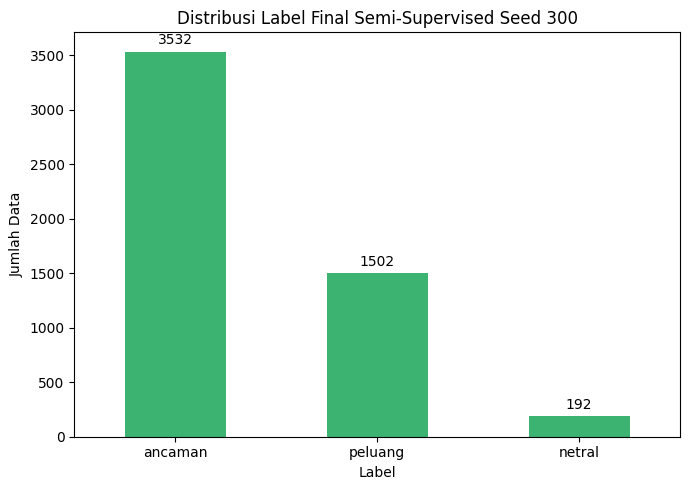

In [17]:
# Grafik ini menunjukkan distribusi label final semi-supervised
# yang siap dipakai untuk tahap pemodelan.

label_distribution = df['label_final'].value_counts(dropna=False).dropna()
label_distribution = label_distribution.rename_axis('label').reset_index(name='jumlah')

display(label_distribution)

ax = label_distribution.plot(
    x='label',
    y='jumlah',
    kind='bar',
    figsize=(7, 5),
    color='mediumseagreen',
    legend=False
)

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.title('Distribusi Label Final Semi-Supervised Seed 300')
plt.xlabel('Label')
plt.ylabel('Jumlah Data')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 4.10 Data Splitting

Pembagian data dilakukan setelah label akhir semi-supervised seed 300 terbentuk. Pada skenario revisi ini, tahap pemodelan difokuskan menjadi klasifikasi biner, yaitu `ancaman` dan `peluang`.

Kategori `netral` tidak digunakan pada tahap modeling karena penelitian ingin menguji kemampuan model membedakan dua arah sentimen utama: risiko/ancaman dan peluang/manfaat. Data `netral` tetap ada pada hasil semi-supervised, tetapi dikeluarkan sebelum data dibagi menjadi train, validation, dan test.

Mitigasi ketidakseimbangan kelas dilakukan dengan:

- stratified split agar proporsi `ancaman` dan `peluang` tetap terjaga pada train, validation, dan test;
- `class_weight='balanced'` pada model SVM;
- class weight pada fine-tuning transformer;
- evaluasi menggunakan classification report sehingga macro average dan weighted average tetap terlihat, bukan hanya accuracy.

In [18]:
# Menyisakan data hasil semi-supervised seed 300 untuk modeling biner.
# Label netral dibuang sebelum split sehingga model hanya membedakan ancaman vs peluang.
# Split dibuat menjadi train/validation/test dengan proporsi 70/10/20.

RANDOM_STATE = 42
TEST_SIZE = 0.20
VALIDATION_SIZE_FROM_REMAINING = 0.125  # 12.5% dari sisa 80% = 10% dari total data

# Modeling akhir hanya memakai dua label utama.
MODEL_LABELS = ['ancaman', 'peluang']
label_order = MODEL_LABELS

df_model_all = df.dropna(subset=['label_final']).copy()
df_removed_from_modeling = df_model_all[~df_model_all['label_final'].isin(MODEL_LABELS)].copy()
df_model = df_model_all[df_model_all['label_final'].isin(MODEL_LABELS)].copy()

label_counts_model = df_model['label_final'].value_counts().reindex(label_order).fillna(0).astype(int)
majority_count = int(label_counts_model.max())
minority_count = int(label_counts_model.min())
imbalance_ratio = majority_count / minority_count if minority_count else np.nan

modeling_filter_summary = pd.DataFrame({
    'metrik': [
        'Jumlah data label final semi-supervised',
        'Jumlah data netral / di luar label modeling yang dibuang',
        'Jumlah data siap modeling biner',
        'Rasio kelas mayoritas : minoritas'
    ],
    'nilai': [
        len(df_model_all),
        len(df_removed_from_modeling),
        len(df_model),
        f'{imbalance_ratio:.2f}:1'
    ]
})

print('Ringkasan filter data untuk modeling biner:')
display(modeling_filter_summary)

print('Distribusi label yang dipakai untuk modeling:')
display(label_counts_model)

df_model.to_csv(
    'Dataset Final Semisupervised Binary.csv',
    sep=';',
    index=False,
    encoding='utf-8-sig'
)

train_val_idx, test_idx = train_test_split(
    df_model.index,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=df_model['label_final']
)

train_idx, val_idx = train_test_split(
    train_val_idx,
    test_size=VALIDATION_SIZE_FROM_REMAINING,
    random_state=RANDOM_STATE,
    stratify=df_model.loc[train_val_idx, 'label_final']
)

X_train_no_stem = df_model.loc[train_idx, 'text_no_stemming']
X_val_no_stem = df_model.loc[val_idx, 'text_no_stemming']
X_test_no_stem = df_model.loc[test_idx, 'text_no_stemming']

X_train_stem = df_model.loc[train_idx, 'text_stemmed']
X_val_stem = df_model.loc[val_idx, 'text_stemmed']
X_test_stem = df_model.loc[test_idx, 'text_stemmed']

y_train = df_model.loc[train_idx, 'label_final']
y_val = df_model.loc[val_idx, 'label_final']
y_test = df_model.loc[test_idx, 'label_final']

print('Jumlah data siap model:', len(df_model))
print('Ukuran data train     :', len(train_idx))
print('Ukuran data validation:', len(val_idx))
print('Ukuran data test      :', len(test_idx))

Ringkasan filter data untuk modeling biner:


,metrik,nilai
0,Jumlah data label final semi-supervised,5226
1,Jumlah data netral / di luar label modeling yang dibuang,192
2,Jumlah data siap modeling biner,5034
3,Rasio kelas mayoritas : minoritas,2.35:1


Distribusi label yang dipakai untuk modeling:


label_final
ancaman    3532
peluang    1502
Name: count, dtype: int64

Jumlah data siap model: 5034
Ukuran data train     : 3523
Ukuran data validation: 504
Ukuran data test      : 1007


### 4.10.1 Visualisasi Distribusi Label Biner pada Data Train, Validation, dan Test

Setelah data `netral` dikeluarkan, distribusi label `ancaman` dan `peluang` ditampilkan kembali. Tujuannya adalah memastikan stratified split menjaga proporsi kelas pada data train, validation, dan test.

,train,validation,test
label_final,,,
ancaman,2471,354,707
peluang,1052,150,300


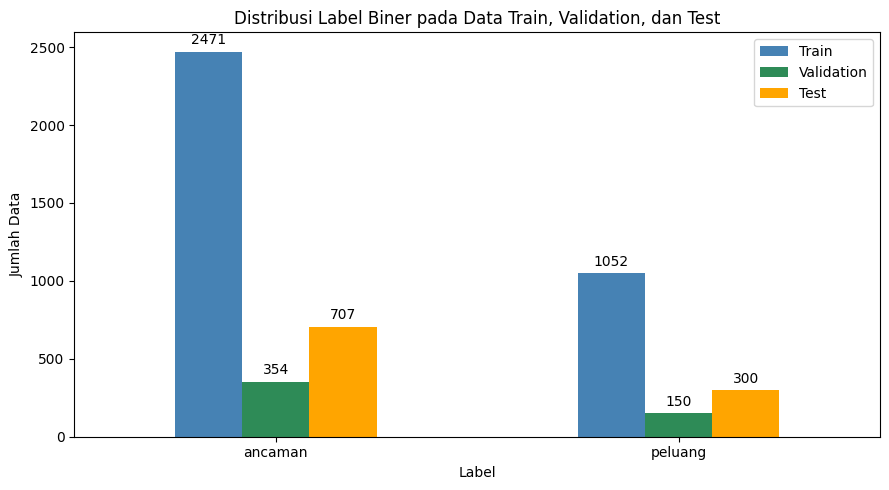

In [19]:
# Visualisasi ini membantu melihat apakah distribusi label biner
# pada data train, validation, dan test tetap proporsional.

split_distribution = pd.DataFrame({
    'train': y_train.value_counts(),
    'validation': y_val.value_counts(),
    'test': y_test.value_counts()
}).reindex(label_order).fillna(0).astype(int)

display(split_distribution)

split_distribution_plot = split_distribution.reset_index()
split_distribution_plot.columns = ['label', 'train', 'validation', 'test']

ax = split_distribution_plot.plot(
    x='label',
    y=['train', 'validation', 'test'],
    kind='bar',
    figsize=(9, 5),
    color=['steelblue', 'seagreen', 'orange']
)

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.title('Distribusi Label Biner pada Data Train, Validation, dan Test')
plt.xlabel('Label')
plt.ylabel('Jumlah Data')
plt.xticks(rotation=0)
plt.legend(['Train', 'Validation', 'Test'])
plt.tight_layout()
plt.show()

## 4.11 Feature Extraction TF-IDF

Pada tahap ini, teks yang telah dipreproses diubah menjadi fitur numerik menggunakan `TF-IDF`. Ekstraksi fitur dilakukan dalam dua skenario, yaitu teks tanpa stemming dan teks dengan stemming, agar pengaruh stemming terhadap representasi fitur dapat dibandingkan.

Proses ini dilakukan sebelum model `SVM` dilatih, karena `SVM` tidak membaca teks secara langsung, melainkan menggunakan masukan dalam bentuk fitur numerik.

In [20]:
# TF-IDF mengubah teks menjadi fitur numerik untuk dua skenario.
# Skenario pertama memakai teks tanpa stemming.
# Skenario kedua memakai teks dengan stemming.

tfidf_no_stem = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True
)

tfidf_stem = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True
)

X_train_no_stem_tfidf = tfidf_no_stem.fit_transform(X_train_no_stem)
X_test_no_stem_tfidf = tfidf_no_stem.transform(X_test_no_stem)

X_train_stem_tfidf = tfidf_stem.fit_transform(X_train_stem)
X_test_stem_tfidf = tfidf_stem.transform(X_test_stem)

print('Bentuk fitur TF-IDF tanpa stemming:', X_train_no_stem_tfidf.shape)
print('Bentuk fitur TF-IDF dengan stemming:', X_train_stem_tfidf.shape)

Bentuk fitur TF-IDF tanpa stemming: (3523, 8808)
Bentuk fitur TF-IDF dengan stemming: (3523, 8241)


## 4.12 Modeling Baseline SVM

Setelah fitur TF-IDF diperoleh, tahap berikutnya adalah melatih model `SVM`. Pemodelan dilakukan pada dua skenario, yaitu menggunakan fitur hasil TF-IDF tanpa stemming dan fitur hasil TF-IDF dengan stemming.

Pada skenario biner ini, `LinearSVC` memakai `class_weight='balanced'` sebagai mitigasi ketidakseimbangan jumlah data antara kelas `ancaman` dan `peluang`.

In [21]:
# SVM dilatih menggunakan fitur hasil TF-IDF.
# Dua model disiapkan untuk membandingkan skenario
# tanpa stemming dan dengan stemming.

svm_no_stem = LinearSVC(class_weight='balanced', random_state=42)
svm_no_stem.fit(X_train_no_stem_tfidf, y_train)
y_pred_no_stem = svm_no_stem.predict(X_test_no_stem_tfidf)
accuracy_no_stem = accuracy_score(y_test, y_pred_no_stem)

svm_stem = LinearSVC(class_weight='balanced', random_state=42)
svm_stem.fit(X_train_stem_tfidf, y_train)
y_pred_stem = svm_stem.predict(X_test_stem_tfidf)
accuracy_stem = accuracy_score(y_test, y_pred_stem)

hasil_baseline = pd.DataFrame([
    {'skenario': 'TF-IDF + SVM tanpa stemming', 'accuracy': accuracy_no_stem},
    {'skenario': 'TF-IDF + SVM dengan stemming', 'accuracy': accuracy_stem},
])

hasil_baseline

,skenario,accuracy
0,TF-IDF + SVM tanpa stemming,0.986097
1,TF-IDF + SVM dengan stemming,0.986097


## 4.13 Evaluasi Baseline TF-IDF + SVM

Setelah kedua skenario baseline dijalankan, hasil evaluasi dapat dibandingkan untuk melihat pengaruh stemming terhadap performa model. Evaluasi ditampilkan dalam bentuk classification report dan confusion matrix.


Accuracy tanpa stemming: 0.9861

Classification report tanpa stemming:
              precision    recall  f1-score   support

     ancaman       0.99      0.99      0.99       707
     peluang       0.98      0.97      0.98       300

    accuracy                           0.99      1007
   macro avg       0.99      0.98      0.98      1007
weighted avg       0.99      0.99      0.99      1007



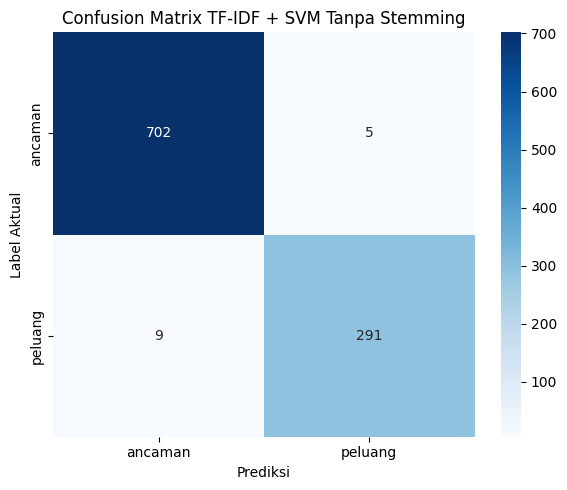



Accuracy dengan stemming: 0.9861

Classification report dengan stemming:
              precision    recall  f1-score   support

     ancaman       0.99      0.99      0.99       707
     peluang       0.98      0.97      0.98       300

    accuracy                           0.99      1007
   macro avg       0.99      0.98      0.98      1007
weighted avg       0.99      0.99      0.99      1007



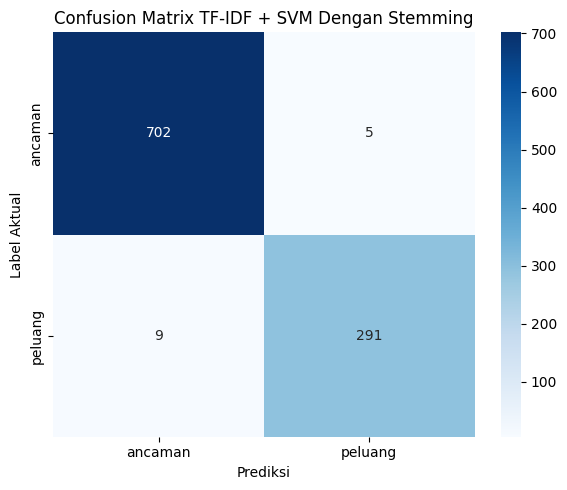

In [22]:
# Menampilkan evaluasi rinci untuk kedua skenario baseline.

def plot_confusion_matrix(cm, labels, title):
    plt.figure(figsize=(6, 5))
    if SEABORN_AVAILABLE:
        sns.heatmap(
            cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=labels,
            yticklabels=labels
        )
    else:
        plt.imshow(cm, cmap='Blues')
        plt.colorbar()
        plt.xticks(range(len(labels)), labels)
        plt.yticks(range(len(labels)), labels)
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                plt.text(j, i, cm[i, j], ha='center', va='center', color='black')
    plt.title(title)
    plt.xlabel('Prediksi')
    plt.ylabel('Label Aktual')
    plt.tight_layout()
    plt.show()

cm_no_stem = confusion_matrix(y_test, y_pred_no_stem, labels=label_order)
cm_stem = confusion_matrix(y_test, y_pred_stem, labels=label_order)

print('Accuracy tanpa stemming:', f'{accuracy_no_stem:.4f}')
print('\nClassification report tanpa stemming:')
print(classification_report(y_test, y_pred_no_stem, labels=label_order, zero_division=0))
plot_confusion_matrix(cm_no_stem, label_order, 'Confusion Matrix TF-IDF + SVM Tanpa Stemming')

print('\n' + '=' * 60 + '\n')

print('Accuracy dengan stemming:', f'{accuracy_stem:.4f}')
print('\nClassification report dengan stemming:')
print(classification_report(y_test, y_pred_stem, labels=label_order, zero_division=0))
plot_confusion_matrix(cm_stem, label_order, 'Confusion Matrix TF-IDF + SVM Dengan Stemming')

## 4.14 Fine-Tuning IndoBERT

Pada tahap ini, model transformer `IndoBERT` digunakan sebagai pembanding terhadap model baseline `TF-IDF + SVM`. Berbeda dengan baseline, masukan untuk IndoBERT tidak melalui preprocessing yang terlalu berat.

Teks yang dipakai untuk IndoBERT adalah teks hasil normalisasi ringan. Dengan cara ini, konteks kalimat masih tetap terjaga dan model dapat membaca susunan kata secara lebih alami.


### 4.14.1 Menyiapkan Teks dan Label untuk IndoBERT

Sebelum proses fine-tuning dilakukan, data perlu disiapkan terlebih dahulu. Pada tahap ini digunakan teks hasil normalisasi ringan yang disimpan dalam kolom `text_light_normalized`, lalu `label_final` hasil semi-supervised seed 300 dipetakan ke bentuk numerik.

Karena skenario modeling dibuat biner, label yang dipakai hanya `ancaman` dan `peluang`. Pembagian data train, validation, dan test tetap memakai indeks yang sama seperti baseline agar perbandingan hasil antar model tetap adil.

In [23]:
# IndoBERT memakai teks hasil normalisasi ringan.
# Teks ini tidak melalui stopword removal, stemming,
# atau penyetaraan kata tidak baku yang lebih agresif.

from sklearn.metrics import f1_score
from sklearn.utils.class_weight import compute_class_weight

df_model['text_for_indobert'] = df_model['text_light_normalized']

label2id = {label: idx for idx, label in enumerate(label_order)}
id2label = {idx: label for label, idx in label2id.items()}

train_indobert = df_model.loc[train_idx, ['text_for_indobert', 'label_final']].copy()
val_indobert = df_model.loc[val_idx, ['text_for_indobert', 'label_final']].copy()
test_indobert = df_model.loc[test_idx, ['text_for_indobert', 'label_final']].copy()

train_indobert['label_id'] = train_indobert['label_final'].map(label2id)
val_indobert['label_id'] = val_indobert['label_final'].map(label2id)
test_indobert['label_id'] = test_indobert['label_final'].map(label2id)

class_ids = np.array([label2id[label] for label in label_order])
class_weight_values = compute_class_weight(
    class_weight='balanced',
    classes=class_ids,
    y=train_indobert['label_id'].to_numpy()
)

class_weight_summary = pd.DataFrame({
    'label': label_order,
    'label_id': class_ids,
    'jumlah_train': train_indobert['label_final'].value_counts().reindex(label_order).fillna(0).astype(int).to_numpy(),
    'class_weight': class_weight_values
})

class_weights_tensor = torch.tensor(class_weight_values, dtype=torch.float) if TORCH_AVAILABLE else None

def make_weighted_trainer_class(base_trainer_class):
    class WeightedLossTrainer(base_trainer_class):
        def __init__(self, *args, class_weights=None, **kwargs):
            super().__init__(*args, **kwargs)
            self.class_weights = class_weights

        def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
            labels = inputs.get('labels')
            outputs = model(**inputs)

            if labels is None:
                loss = outputs.loss
            else:
                logits = outputs.logits
                weight = self.class_weights.to(logits.device) if self.class_weights is not None else None
                loss_fct = torch.nn.CrossEntropyLoss(weight=weight)
                loss = loss_fct(logits.view(-1, model.config.num_labels), labels.view(-1))

            return (loss, outputs) if return_outputs else loss

    return WeightedLossTrainer

print('Jumlah data train IndoBERT     :', len(train_indobert))
print('Jumlah data validation IndoBERT:', len(val_indobert))
print('Jumlah data test IndoBERT      :', len(test_indobert))

print('Bobot kelas untuk mitigasi imbalance pada model transformer:')
display(class_weight_summary)

display(train_indobert.head())

Jumlah data train IndoBERT     : 3523
Jumlah data validation IndoBERT: 504
Jumlah data test IndoBERT      : 1007
Bobot kelas untuk mitigasi imbalance pada model transformer:


,label,label_id,jumlah_train,class_weight
0,ancaman,0,2471,0.712869
1,peluang,1,1052,1.674430


,text_for_indobert,label_final,label_id
905,crypto dan ai akan menjadi kunci dimasa depan 1 ai akan menggantikan seluruh pekerjaan yang ada 2 crypto akan menggantikan sistem keuangan dan keamanan yang ada sekarang pilihannya hanya 2 yaitu b...,ancaman,0
4970,banyak orang mulai sadar di sisi positifnya ai membuka ruang baru bagi akuntan untuk naik kelas dari kerja teknis ke analisis evaluasi dan pengambilan keputusan,peluang,1
2080,oh iya sekedar mengingatkan pakai sketchup untuk membantu pekerjaan membuat komik tidak sama dengan memakai ai generated machine,ancaman,0
4233,beberapa proses kerja analis data sekarang sudah bisa dikerjakan model ai dari awal sampai akhir dan itu jelas menambah risiko pengurangan tenaga kerja posisi yang tugasnya terlalu standar biasany...,peluang,1
4675,buat yang kerja di bidang ini kalau tugas penulis konten isinya input data rekap bikin laporan rutin dan follow up template wajar kalau banyak orang merasa posisi ini paling cepat terdampak otomat...,peluang,1


### 4.14.2 Tokenisasi dengan Tokenizer Bawaan IndoBERT

Pada model `IndoBERT`, tokenisasi tidak dilakukan secara manual. Tokenisasi dilakukan menggunakan tokenizer bawaan model agar pemecahan token sesuai dengan vocabulary yang digunakan saat pretraining.

Model yang dipilih pada notebook ini adalah `indobenchmark/indobert-base-p1`. Jika library yang dibutuhkan belum tersedia, bagian ini dapat dijalankan setelah dependensi dipasang.


In [24]:
# Tokenisasi dilakukan dengan tokenizer bawaan IndoBERT.
# Jika library transformers atau datasets belum tersedia,
# notebook akan memberi catatan tanpa menghentikan seluruh alur.

model_name_indobert = 'indobenchmark/indobert-base-p1'

try:
    from datasets import Dataset
    from transformers import AutoTokenizer

    tokenizer_indobert = AutoTokenizer.from_pretrained(model_name_indobert)

    train_dataset_indobert = Dataset.from_pandas(
        train_indobert[['text_for_indobert', 'label_id']].rename(
            columns={'text_for_indobert': 'text', 'label_id': 'label'}
        ),
        preserve_index=False
    )
    val_dataset_indobert = Dataset.from_pandas(
        val_indobert[['text_for_indobert', 'label_id']].rename(
            columns={'text_for_indobert': 'text', 'label_id': 'label'}
        ),
        preserve_index=False
    )
    test_dataset_indobert = Dataset.from_pandas(
        test_indobert[['text_for_indobert', 'label_id']].rename(
            columns={'text_for_indobert': 'text', 'label_id': 'label'}
        ),
        preserve_index=False
    )

    def tokenize_indobert(batch):
        return tokenizer_indobert(
            batch['text'],
            truncation=True,
            padding='max_length',
            max_length=128
        )

    tokenized_train_indobert = train_dataset_indobert.map(tokenize_indobert, batched=True)
    tokenized_val_indobert = val_dataset_indobert.map(tokenize_indobert, batched=True)
    tokenized_test_indobert = test_dataset_indobert.map(tokenize_indobert, batched=True)

    print('Tokenisasi IndoBERT berhasil disiapkan.')
    display(tokenized_train_indobert.select(range(min(3, len(tokenized_train_indobert)))))
except ImportError:
    print('Library transformers atau datasets belum terpasang. Tahap tokenisasi IndoBERT belum dijalankan.')

c:\Users\Mirza\OneDrive - Universitas Multimedia Nusantara\CODING SKRIPSI FINAL\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Map: 100%|██████████| 1007/1007 [00:00<00:00, 5094.26 examples/s]


Tokenisasi IndoBERT berhasil disiapkan.


Dataset({
    features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 3
})

### 4.14.3 Menyiapkan Fine-Tuning IndoBERT

Setelah tokenisasi selesai, model `IndoBERT` dapat di-fine-tune menggunakan data train. Selama training, data validation digunakan untuk mengevaluasi performa tiap epoch dan memilih checkpoint terbaik. Data test tidak digunakan pada tahap ini agar evaluasi akhir tetap adil.

Parameter pelatihan pada notebook ini disiapkan sebagai titik awal. Nilainya masih dapat disesuaikan kembali jika pada proses eksperimen diperlukan penyesuaian yang lebih lanjut.

In [25]:
# Fine-tuning IndoBERT disiapkan dengan Trainer dari Hugging Face.
# Eval dataset memakai validation set, bukan test set.
# Class weight dipakai sebagai mitigasi imbalance pada data train.

indobert_trainer = None
accuracy_indobert = np.nan
y_pred_indobert = None
y_test_indobert = test_indobert['label_final'].tolist()

try:
    if not TORCH_AVAILABLE:
        raise ImportError('PyTorch belum tersedia.')

    from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer

    WeightedLossTrainer = make_weighted_trainer_class(Trainer)

    model_indobert = AutoModelForSequenceClassification.from_pretrained(
        model_name_indobert,
        num_labels=len(label2id),
        id2label=id2label,
        label2id=label2id
    )

    training_args_indobert = TrainingArguments(
        output_dir='outputs/indobert_results',
        eval_strategy='epoch',
        save_strategy='epoch',
        logging_strategy='epoch',
        learning_rate=2e-5,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        num_train_epochs=3,
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model='macro_f1',
        greater_is_better=True,
        save_total_limit=1,
        report_to='none',
        fp16=USE_CUDA,
        dataloader_pin_memory=USE_CUDA
    )

    def compute_metrics_indobert(eval_pred):
        logits, labels = eval_pred
        predictions = np.argmax(logits, axis=1)
        return {
            'accuracy': accuracy_score(labels, predictions),
            'macro_f1': f1_score(labels, predictions, average='macro', zero_division=0),
            'weighted_f1': f1_score(labels, predictions, average='weighted', zero_division=0)
        }

    indobert_trainer = WeightedLossTrainer(
        model=model_indobert,
        args=training_args_indobert,
        train_dataset=tokenized_train_indobert,
        eval_dataset=tokenized_val_indobert,
        processing_class=tokenizer_indobert,
        compute_metrics=compute_metrics_indobert,
        class_weights=class_weights_tensor
    )

    print('Trainer IndoBERT sudah siap. Jalankan baris berikut saat ingin memulai training:')
    print('indobert_trainer.train()')
except Exception as e:
    print('Trainer IndoBERT belum siap dijalankan:', e)

[transformers] You passed `num_labels=2` which is incompatible to the `id2label` map of length `5`.
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 32265.12it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainer IndoBERT sudah siap. Jalankan baris berikut saat ingin memulai training:
indobert_trainer.train()


### 4.14.4 Menjalankan Training IndoBERT

Setelah `Trainer` berhasil disiapkan, proses berikutnya adalah menjalankan training pada data train. Pada tahap ini, bobot classifier yang sebelumnya masih baru akan mulai menyesuaikan diri dengan pola data pada penelitian.

Durasi training dapat berbeda-beda tergantung kemampuan perangkat yang digunakan. Setelah training selesai, hasil evaluasi akhir dapat dijalankan pada bagian berikutnya.


In [26]:
# Cell ini dipakai untuk menjalankan training IndoBERT.
# Jalankan setelah trainer berhasil disiapkan.

if indobert_trainer is None:
    print('Trainer IndoBERT belum siap. Jalankan tahap persiapan trainer terlebih dahulu.')
else:
    train_result_indobert = indobert_trainer.train()
    print('Training IndoBERT selesai.')
    train_result_indobert

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,0.181766,0.059876,0.986111,0.983358,0.986098
2,0.068894,0.069323,0.992063,0.990434,0.992032
3,0.021799,0.064377,0.990079,0.988019,0.990030


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.37s/it]


Training IndoBERT selesai.


### 4.14.5 Evaluasi IndoBERT

Setelah proses fine-tuning selesai, hasil prediksi pada data test dapat dievaluasi menggunakan metrik yang sama seperti baseline. Dengan demikian, hasil `IndoBERT` dapat dibandingkan secara langsung terhadap `TF-IDF + SVM`.

Visualisasi confusion matrix juga dapat digunakan agar pola prediksi yang benar dan salah lebih mudah diamati.


Accuracy IndoBERT: 0.9871

Classification report IndoBERT:
              precision    recall  f1-score   support

     ancaman       0.99      0.99      0.99       707
     peluang       0.99      0.97      0.98       300

    accuracy                           0.99      1007
   macro avg       0.99      0.98      0.98      1007
weighted avg       0.99      0.99      0.99      1007



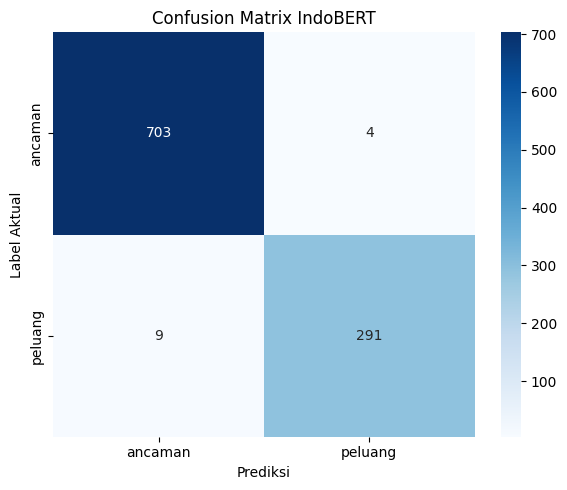

In [27]:
# Cell ini dijalankan setelah proses training selesai.
# Jika trainer belum dijalankan, notebook hanya menampilkan pengingat singkat.

if indobert_trainer is None:
    print('Trainer IndoBERT belum siap. Lengkapi tahap tokenisasi dan inisialisasi model terlebih dahulu.')
else:
    if not hasattr(indobert_trainer, 'state') or indobert_trainer.state.global_step == 0:
        print('Silakan jalankan indobert_trainer.train() terlebih dahulu sebelum evaluasi akhir.')
    else:
        pred_output_indobert = indobert_trainer.predict(tokenized_test_indobert)
        pred_ids_indobert = np.argmax(pred_output_indobert.predictions, axis=1)
        y_pred_indobert = [id2label[i] for i in pred_ids_indobert]
        accuracy_indobert = accuracy_score(y_test_indobert, y_pred_indobert)

        print('Accuracy IndoBERT:', f'{accuracy_indobert:.4f}')
        print('\nClassification report IndoBERT:')
        print(classification_report(y_test_indobert, y_pred_indobert, labels=label_order, zero_division=0))

        cm_indobert = confusion_matrix(y_test_indobert, y_pred_indobert, labels=label_order)
        plot_confusion_matrix(cm_indobert, label_order, 'Confusion Matrix IndoBERT')

## 4.15 Fine-Tuning IndoBERTweet

Pada tahap ini, model `IndoBERTweet` digunakan sebagai pembanding lanjutan karena model ini memang dikembangkan untuk data bergaya media sosial. Dengan karakter tersebut, IndoBERTweet diharapkan lebih peka terhadap bentuk bahasa tweet yang cenderung singkat, tidak selalu formal, dan kadang memakai variasi penulisan.

Seperti pada IndoBERT, masukan untuk IndoBERTweet tetap menggunakan teks hasil normalisasi ringan agar konteks kalimat tetap terjaga.


### 4.15.1 Menyiapkan Teks dan Label untuk IndoBERTweet

Data yang digunakan pada tahap ini tetap berasal dari dataset dan split biner yang sama seperti model sebelumnya. Tujuannya agar hasil evaluasi antara baseline, IndoBERT, dan IndoBERTweet dapat dibandingkan secara adil.

Teks input diambil dari kolom `text_light_normalized`, sedangkan label menggunakan `label_final` hasil semi-supervised seed 300 yang sudah difilter menjadi `ancaman` dan `peluang`.

In [28]:
# IndoBERTweet juga memakai teks hasil normalisasi ringan.
# Split data tetap sama agar perbandingan antar model adil.

df_model['text_for_indobertweet'] = df_model['text_light_normalized']

train_indobertweet = df_model.loc[train_idx, ['text_for_indobertweet', 'label_final']].copy()
val_indobertweet = df_model.loc[val_idx, ['text_for_indobertweet', 'label_final']].copy()
test_indobertweet = df_model.loc[test_idx, ['text_for_indobertweet', 'label_final']].copy()

train_indobertweet['label_id'] = train_indobertweet['label_final'].map(label2id)
val_indobertweet['label_id'] = val_indobertweet['label_final'].map(label2id)
test_indobertweet['label_id'] = test_indobertweet['label_final'].map(label2id)

print('Jumlah data train IndoBERTweet     :', len(train_indobertweet))
print('Jumlah data validation IndoBERTweet:', len(val_indobertweet))
print('Jumlah data test IndoBERTweet      :', len(test_indobertweet))

display(train_indobertweet.head())

Jumlah data train IndoBERTweet     : 3523
Jumlah data validation IndoBERTweet: 504
Jumlah data test IndoBERTweet      : 1007


,text_for_indobertweet,label_final,label_id
905,crypto dan ai akan menjadi kunci dimasa depan 1 ai akan menggantikan seluruh pekerjaan yang ada 2 crypto akan menggantikan sistem keuangan dan keamanan yang ada sekarang pilihannya hanya 2 yaitu b...,ancaman,0
4970,banyak orang mulai sadar di sisi positifnya ai membuka ruang baru bagi akuntan untuk naik kelas dari kerja teknis ke analisis evaluasi dan pengambilan keputusan,peluang,1
2080,oh iya sekedar mengingatkan pakai sketchup untuk membantu pekerjaan membuat komik tidak sama dengan memakai ai generated machine,ancaman,0
4233,beberapa proses kerja analis data sekarang sudah bisa dikerjakan model ai dari awal sampai akhir dan itu jelas menambah risiko pengurangan tenaga kerja posisi yang tugasnya terlalu standar biasany...,peluang,1
4675,buat yang kerja di bidang ini kalau tugas penulis konten isinya input data rekap bikin laporan rutin dan follow up template wajar kalau banyak orang merasa posisi ini paling cepat terdampak otomat...,peluang,1


### 4.15.2 Tokenisasi dengan Tokenizer Bawaan IndoBERTweet

Tokenisasi pada IndoBERTweet dilakukan menggunakan tokenizer bawaan model. Langkah ini penting karena vocabulary dan cara pemotongan token pada IndoBERTweet berbeda dari IndoBERT biasa.

Model yang dipakai pada notebook ini adalah `indolem/indobertweet-base-uncased`. Jika dependensinya sudah tersedia, tahap tokenisasi dapat dijalankan langsung pada notebook.


In [29]:
# Tokenisasi dilakukan dengan tokenizer bawaan IndoBERTweet.
# Struktur langkahnya dibuat mirip dengan IndoBERT agar lebih mudah dibandingkan.

model_name_indobertweet = 'indolem/indobertweet-base-uncased'

try:
    from datasets import Dataset
    from transformers import AutoTokenizer

    tokenizer_indobertweet = AutoTokenizer.from_pretrained(model_name_indobertweet)

    train_dataset_indobertweet = Dataset.from_pandas(
        train_indobertweet[['text_for_indobertweet', 'label_id']].rename(
            columns={'text_for_indobertweet': 'text', 'label_id': 'label'}
        ),
        preserve_index=False
    )
    val_dataset_indobertweet = Dataset.from_pandas(
        val_indobertweet[['text_for_indobertweet', 'label_id']].rename(
            columns={'text_for_indobertweet': 'text', 'label_id': 'label'}
        ),
        preserve_index=False
    )
    test_dataset_indobertweet = Dataset.from_pandas(
        test_indobertweet[['text_for_indobertweet', 'label_id']].rename(
            columns={'text_for_indobertweet': 'text', 'label_id': 'label'}
        ),
        preserve_index=False
    )

    def tokenize_indobertweet(batch):
        return tokenizer_indobertweet(
            batch['text'],
            truncation=True,
            padding='max_length',
            max_length=128
        )

    tokenized_train_indobertweet = train_dataset_indobertweet.map(tokenize_indobertweet, batched=True)
    tokenized_val_indobertweet = val_dataset_indobertweet.map(tokenize_indobertweet, batched=True)
    tokenized_test_indobertweet = test_dataset_indobertweet.map(tokenize_indobertweet, batched=True)

    print('Tokenisasi IndoBERTweet berhasil disiapkan.')
    display(tokenized_train_indobertweet.select(range(min(3, len(tokenized_train_indobertweet)))))
except ImportError:
    print('Library transformers atau datasets belum terpasang. Tahap tokenisasi IndoBERTweet belum dijalankan.')

Map: 100%|██████████| 1007/1007 [00:00<00:00, 10346.26 examples/s]

Tokenisasi IndoBERTweet berhasil disiapkan.


Dataset({
    features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 3
})

### 4.15.3 Menyiapkan Fine-Tuning IndoBERTweet

Setelah tokenisasi selesai, model IndoBERTweet disiapkan untuk proses fine-tuning. Parameter awal yang digunakan dibuat serupa dengan IndoBERT agar perbandingan performa lebih mudah dilakukan. Sama seperti IndoBERT, data validation digunakan saat training dan data test disimpan untuk evaluasi akhir.

Jika pada pelaksanaan eksperimen dibutuhkan penyesuaian, nilai parameter seperti `num_train_epochs`, `learning_rate`, atau `batch_size` masih dapat diubah kembali.

In [30]:
# Fine-tuning IndoBERTweet disiapkan dengan Trainer yang terpisah
# dari IndoBERT karena model dan tokenizer yang dipakai juga berbeda.
# Eval dataset memakai validation set, bukan test set.
# Class weight dipakai sebagai mitigasi imbalance pada data train.

indobertweet_trainer = None
accuracy_indobertweet = np.nan
y_pred_indobertweet = None
y_test_indobertweet = test_indobertweet['label_final'].tolist()

try:
    if not TORCH_AVAILABLE:
        raise ImportError('PyTorch belum tersedia.')

    from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer

    WeightedLossTrainer = make_weighted_trainer_class(Trainer)

    model_indobertweet = AutoModelForSequenceClassification.from_pretrained(
        model_name_indobertweet,
        num_labels=len(label2id),
        id2label=id2label,
        label2id=label2id
    )

    training_args_indobertweet = TrainingArguments(
        output_dir='outputs/indobertweet_results',
        eval_strategy='epoch',
        save_strategy='epoch',
        logging_strategy='epoch',
        learning_rate=2e-5,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        num_train_epochs=3,
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model='macro_f1',
        greater_is_better=True,
        save_total_limit=1,
        report_to='none',
        fp16=USE_CUDA,
        dataloader_pin_memory=USE_CUDA
    )

    def compute_metrics_indobertweet(eval_pred):
        logits, labels = eval_pred
        predictions = np.argmax(logits, axis=1)
        return {
            'accuracy': accuracy_score(labels, predictions),
            'macro_f1': f1_score(labels, predictions, average='macro', zero_division=0),
            'weighted_f1': f1_score(labels, predictions, average='weighted', zero_division=0)
        }

    indobertweet_trainer = WeightedLossTrainer(
        model=model_indobertweet,
        args=training_args_indobertweet,
        train_dataset=tokenized_train_indobertweet,
        eval_dataset=tokenized_val_indobertweet,
        processing_class=tokenizer_indobertweet,
        compute_metrics=compute_metrics_indobertweet,
        class_weights=class_weights_tensor
    )

    print('Trainer IndoBERTweet sudah siap. Jalankan cell training pada tahap berikutnya.')
except Exception as e:
    print('Trainer IndoBERTweet belum siap dijalankan:', e)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 42302.29it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: indolem/indobertweet-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing 

Trainer IndoBERTweet sudah siap. Jalankan cell training pada tahap berikutnya.


### 4.15.4 Menjalankan Training IndoBERTweet

Pada tahap ini, model IndoBERTweet mulai dilatih menggunakan data train. Proses ini akan memperbarui bobot classifier agar sesuai dengan karakter data pada penelitian.

Waktu training dapat bervariasi tergantung kemampuan perangkat, jumlah epoch, dan panjang input token yang digunakan.


In [31]:
# Cell ini dipakai untuk menjalankan training IndoBERTweet.
# Jalankan setelah trainer berhasil disiapkan.

if indobertweet_trainer is None:
    print('Trainer IndoBERTweet belum siap. Jalankan tahap persiapan trainer terlebih dahulu.')
else:
    train_result_indobertweet = indobertweet_trainer.train()
    print('Training IndoBERTweet selesai.')
    train_result_indobertweet

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,0.153412,0.063271,0.988095,0.985708,0.988072
2,0.066158,0.055987,0.990079,0.988066,0.990050
3,0.025167,0.069481,0.992063,0.990434,0.992032


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.42it/s]


Training IndoBERTweet selesai.


### 4.15.5 Evaluasi IndoBERTweet

Setelah training selesai, hasil prediksi model pada data test dievaluasi dengan metrik yang sama seperti model sebelumnya. Dengan demikian, hasil IndoBERTweet dapat dibandingkan secara langsung terhadap baseline dan IndoBERT.

Confusion matrix divisualisasikan kembali agar distribusi prediksi yang benar dan yang keliru dapat diamati dengan lebih mudah.


Accuracy IndoBERTweet: 0.9871

Classification report IndoBERTweet:
              precision    recall  f1-score   support

     ancaman       0.99      0.99      0.99       707
     peluang       0.98      0.97      0.98       300

    accuracy                           0.99      1007
   macro avg       0.99      0.98      0.98      1007
weighted avg       0.99      0.99      0.99      1007



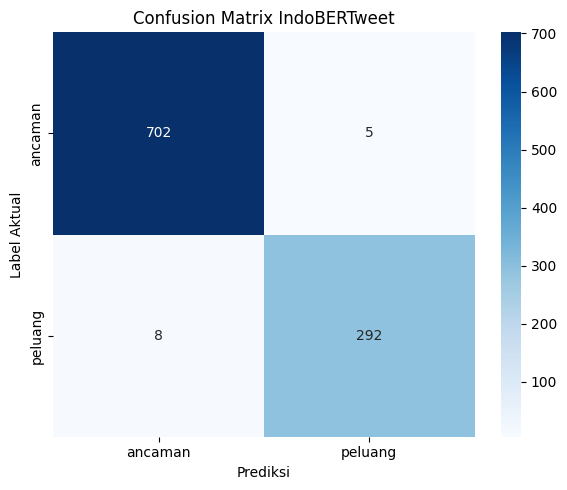

In [32]:
# Cell ini dijalankan setelah proses training selesai.
# Jika trainer belum dijalankan, notebook hanya menampilkan pengingat singkat.

if indobertweet_trainer is None:
    print('Trainer IndoBERTweet belum siap. Lengkapi tahap tokenisasi dan inisialisasi model terlebih dahulu.')
else:
    if not hasattr(indobertweet_trainer, 'state') or indobertweet_trainer.state.global_step == 0:
        print('Silakan jalankan cell training IndoBERTweet terlebih dahulu sebelum evaluasi akhir.')
    else:
        pred_output_indobertweet = indobertweet_trainer.predict(tokenized_test_indobertweet)
        pred_ids_indobertweet = np.argmax(pred_output_indobertweet.predictions, axis=1)
        y_pred_indobertweet = [id2label[i] for i in pred_ids_indobertweet]
        accuracy_indobertweet = accuracy_score(y_test_indobertweet, y_pred_indobertweet)

        print('Accuracy IndoBERTweet:', f'{accuracy_indobertweet:.4f}')
        print('\nClassification report IndoBERTweet:')
        print(classification_report(y_test_indobertweet, y_pred_indobertweet, labels=label_order, zero_division=0))

        cm_indobertweet = confusion_matrix(y_test_indobertweet, y_pred_indobertweet, labels=label_order)
        plot_confusion_matrix(cm_indobertweet, label_order, 'Confusion Matrix IndoBERTweet')

### 4.15.6 Skenario Pembanding IndoBERTweet tanpa Normalisasi

Untuk melihat apakah proses normalisasi memengaruhi performa IndoBERTweet, dibuat satu skenario pembanding tambahan. Pada skenario ini, teks yang dipakai lebih mendekati bentuk aslinya, yaitu langsung dari kolom `full_text` dengan pembersihan yang sangat ringan.

Tujuan langkah ini adalah membandingkan apakah IndoBERTweet bekerja lebih baik saat karakter asli tweet masih dipertahankan.


In [33]:
# Skenario pembanding ini memakai teks yang lebih dekat ke bentuk tweet asli.
# Pembersihan hanya dilakukan secara ringan agar karakter teks tetap terjaga.

def prepare_raw_tweet_text(text):
    text = str(text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df_model['text_for_indobertweet_raw'] = df_model['full_text'].apply(prepare_raw_tweet_text)

train_indobertweet_raw = df_model.loc[train_idx, ['text_for_indobertweet_raw', 'label_final']].copy()
val_indobertweet_raw = df_model.loc[val_idx, ['text_for_indobertweet_raw', 'label_final']].copy()
test_indobertweet_raw = df_model.loc[test_idx, ['text_for_indobertweet_raw', 'label_final']].copy()

train_indobertweet_raw['label_id'] = train_indobertweet_raw['label_final'].map(label2id)
val_indobertweet_raw['label_id'] = val_indobertweet_raw['label_final'].map(label2id)
test_indobertweet_raw['label_id'] = test_indobertweet_raw['label_final'].map(label2id)

display(train_indobertweet_raw.head())

,text_for_indobertweet_raw,label_final,label_id
905,Crypto dan AI akan menjadi kunci dimasa depan 1. AI akan menggantikan seluruh pekerjaan yang ada 2.crypto akan menggantikan sistem keuangan dan keamanan yang ada Sekarang pilihannya hanya 2 yaitu ...,ancaman,0
4970,"Banyak orang mulai sadar, di sisi positifnya, AI membuka ruang baru bagi akuntan untuk naik kelas dari kerja teknis ke analisis, evaluasi, dan pengambilan keputusan.",peluang,1
2080,oh iya sekedar mengingatkan pakai sketchup untuk membantu pekerjaan membuat komik tidak sama dengan memakai AI generated machine,ancaman,0
4233,"beberapa proses kerja analis data sekarang sudah bisa dikerjakan model AI dari awal sampai akhir, dan itu jelas menambah risiko pengurangan tenaga kerja. Posisi yang tugasnya terlalu standar biasa...",peluang,1
4675,"Buat yang kerja di bidang ini, kalau tugas penulis konten isinya input data, rekap, bikin laporan rutin, dan follow up template, wajar kalau banyak orang merasa posisi ini paling cepat terdampak o...",peluang,1


### 4.15.7 Tokenisasi dan Trainer untuk Skenario Pembanding

Langkah tokenisasi dan penyiapan trainer pada skenario pembanding dibuat terpisah dari skenario utama. Hal ini dilakukan agar hasil eksperimen tidak saling menimpa dan tetap mudah dibandingkan.


In [34]:
# Tokenisasi dan trainer untuk skenario pembanding disiapkan terpisah.

indobertweet_raw_trainer = None
accuracy_indobertweet_raw = np.nan
y_pred_indobertweet_raw = None
y_test_indobertweet_raw = test_indobertweet_raw['label_final'].tolist()

try:
    if not TORCH_AVAILABLE:
        raise ImportError('PyTorch belum tersedia.')

    from datasets import Dataset
    from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer

    tokenizer_indobertweet_raw = AutoTokenizer.from_pretrained(model_name_indobertweet)

    train_dataset_indobertweet_raw = Dataset.from_pandas(
        train_indobertweet_raw[['text_for_indobertweet_raw', 'label_id']].rename(
            columns={'text_for_indobertweet_raw': 'text', 'label_id': 'label'}
        ),
        preserve_index=False
    )
    val_dataset_indobertweet_raw = Dataset.from_pandas(
        val_indobertweet_raw[['text_for_indobertweet_raw', 'label_id']].rename(
            columns={'text_for_indobertweet_raw': 'text', 'label_id': 'label'}
        ),
        preserve_index=False
    )
    test_dataset_indobertweet_raw = Dataset.from_pandas(
        test_indobertweet_raw[['text_for_indobertweet_raw', 'label_id']].rename(
            columns={'text_for_indobertweet_raw': 'text', 'label_id': 'label'}
        ),
        preserve_index=False
    )

    def tokenize_indobertweet_raw(batch):
        return tokenizer_indobertweet_raw(
            batch['text'],
            truncation=True,
            padding='max_length',
            max_length=128
        )

    tokenized_train_indobertweet_raw = train_dataset_indobertweet_raw.map(tokenize_indobertweet_raw, batched=True)
    tokenized_val_indobertweet_raw = val_dataset_indobertweet_raw.map(tokenize_indobertweet_raw, batched=True)
    tokenized_test_indobertweet_raw = test_dataset_indobertweet_raw.map(tokenize_indobertweet_raw, batched=True)

    model_indobertweet_raw = AutoModelForSequenceClassification.from_pretrained(
        model_name_indobertweet,
        num_labels=len(label2id),
        id2label=id2label,
        label2id=label2id
    )

    training_args_indobertweet_raw = TrainingArguments(
        output_dir='outputs/indobertweet_raw_results',
        eval_strategy='epoch',
        save_strategy='epoch',
        logging_strategy='epoch',
        learning_rate=2e-5,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        num_train_epochs=3,
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model='macro_f1',
        greater_is_better=True,
        save_total_limit=1,
        report_to='none',
        fp16=USE_CUDA,
        dataloader_pin_memory=USE_CUDA
    )

    def compute_metrics_indobertweet_raw(eval_pred):
        logits, labels = eval_pred
        predictions = np.argmax(logits, axis=1)
        return {
            'accuracy': accuracy_score(labels, predictions),
            'macro_f1': f1_score(labels, predictions, average='macro', zero_division=0),
            'weighted_f1': f1_score(labels, predictions, average='weighted', zero_division=0)
        }

    WeightedLossTrainer = make_weighted_trainer_class(Trainer)

    indobertweet_raw_trainer = WeightedLossTrainer(
        model=model_indobertweet_raw,
        args=training_args_indobertweet_raw,
        train_dataset=tokenized_train_indobertweet_raw,
        eval_dataset=tokenized_val_indobertweet_raw,
        processing_class=tokenizer_indobertweet_raw,
        compute_metrics=compute_metrics_indobertweet_raw,
        class_weights=class_weights_tensor
    )

    print('Trainer IndoBERTweet skenario pembanding sudah siap.')
except Exception as e:
    print('Skenario pembanding IndoBERTweet belum siap dijalankan:', e)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 31294.91it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: indolem/indobertweet-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing 

Trainer IndoBERTweet skenario pembanding sudah siap.


### 4.15.8 Menjalankan Training Skenario Pembanding

Setelah trainer pembanding siap, training dapat dijalankan dengan langkah yang sama seperti skenario utama. Hasil dari skenario ini nantinya dibandingkan dengan IndoBERTweet yang memakai teks hasil normalisasi.


In [35]:
# Jalankan training untuk skenario IndoBERTweet tanpa normalisasi.

if indobertweet_raw_trainer is None:
    print('Trainer pembanding belum siap. Jalankan tahap persiapan terlebih dahulu.')
else:
    train_result_indobertweet_raw = indobertweet_raw_trainer.train()
    print('Training IndoBERTweet skenario pembanding selesai.')
    train_result_indobertweet_raw

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,0.149644,0.071791,0.978175,0.974047,0.978236
2,0.067217,0.054866,0.990079,0.988066,0.990050
3,0.017818,0.074167,0.990079,0.988066,0.990050


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.71it/s]


Training IndoBERTweet skenario pembanding selesai.


### 4.15.9 Evaluasi Skenario Pembanding

Tahap ini digunakan untuk melihat hasil akhir dari IndoBERTweet yang memakai teks lebih dekat ke bentuk aslinya. Hasil evaluasi dapat dibandingkan dengan skenario utama untuk melihat pengaruh normalisasi terhadap performa model.


Accuracy IndoBERTweet tanpa normalisasi: 0.9791

Classification report IndoBERTweet tanpa normalisasi:
              precision    recall  f1-score   support

     ancaman       0.99      0.98      0.99       707
     peluang       0.96      0.97      0.97       300

    accuracy                           0.98      1007
   macro avg       0.97      0.98      0.98      1007
weighted avg       0.98      0.98      0.98      1007



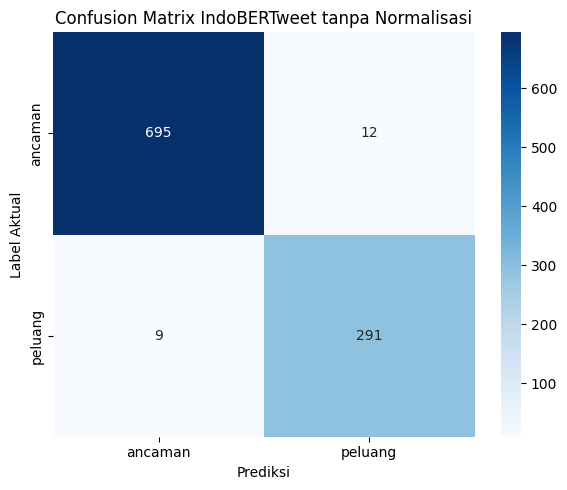

In [36]:
# Evaluasi akhir untuk skenario pembanding IndoBERTweet.

if indobertweet_raw_trainer is None:
    print('Trainer pembanding belum siap. Lengkapi tahap sebelumnya terlebih dahulu.')
else:
    if not hasattr(indobertweet_raw_trainer, 'state') or indobertweet_raw_trainer.state.global_step == 0:
        print('Silakan jalankan cell training skenario pembanding terlebih dahulu sebelum evaluasi akhir.')
    else:
        pred_output_indobertweet_raw = indobertweet_raw_trainer.predict(tokenized_test_indobertweet_raw)
        pred_ids_indobertweet_raw = np.argmax(pred_output_indobertweet_raw.predictions, axis=1)
        y_pred_indobertweet_raw = [id2label[i] for i in pred_ids_indobertweet_raw]
        accuracy_indobertweet_raw = accuracy_score(y_test_indobertweet_raw, y_pred_indobertweet_raw)

        print('Accuracy IndoBERTweet tanpa normalisasi:', f'{accuracy_indobertweet_raw:.4f}')
        print('\nClassification report IndoBERTweet tanpa normalisasi:')
        print(classification_report(y_test_indobertweet_raw, y_pred_indobertweet_raw, labels=label_order, zero_division=0))

        cm_indobertweet_raw = confusion_matrix(y_test_indobertweet_raw, y_pred_indobertweet_raw, labels=label_order)
        plot_confusion_matrix(cm_indobertweet_raw, label_order, 'Confusion Matrix IndoBERTweet tanpa Normalisasi')

## 4.16 Rekap Evaluasi Model

Rekap ini membandingkan seluruh model pada skenario biner `ancaman` dan `peluang` setelah label `netral` dikeluarkan dari data modeling.

In [37]:
# Tabel rekap bisa diisi bertahap sesuai hasil eksperimen.

hasil_model = pd.DataFrame([
    {
        'model': 'TF-IDF + SVM tanpa stemming',
        'accuracy': accuracy_no_stem if 'accuracy_no_stem' in globals() else np.nan,
        'catatan': 'Baseline biner tanpa stemming; class_weight balanced'
    },
    {
        'model': 'TF-IDF + SVM dengan stemming',
        'accuracy': accuracy_stem if 'accuracy_stem' in globals() else np.nan,
        'catatan': 'Baseline biner dengan stemming; class_weight balanced'
    },
    {
        'model': 'IndoBERT',
        'accuracy': accuracy_indobert if 'accuracy_indobert' in globals() else np.nan,
        'catatan': 'Fine-tuning biner IndoBERT; class weight dan validation dipakai saat training'
    },
    {
        'model': 'IndoBERTweet',
        'accuracy': accuracy_indobertweet if 'accuracy_indobertweet' in globals() else np.nan,
        'catatan': 'Fine-tuning biner IndoBERTweet dengan text_light_normalized dan class weight'
    },
    {
        'model': 'IndoBERTweet tanpa normalisasi',
        'accuracy': accuracy_indobertweet_raw if 'accuracy_indobertweet_raw' in globals() else np.nan,
        'catatan': 'Fine-tuning biner IndoBERTweet dengan full_text dan class weight'
    }
])

hasil_model

,model,accuracy,catatan
0,TF-IDF + SVM tanpa stemming,0.986097,Baseline biner tanpa stemming; class_weight balanced
1,TF-IDF + SVM dengan stemming,0.986097,Baseline biner dengan stemming; class_weight balanced
2,IndoBERT,0.987090,Fine-tuning biner IndoBERT; class weight dan validation dipakai saat training
3,IndoBERTweet,0.987090,Fine-tuning biner IndoBERTweet dengan text_light_normalized dan class weight
4,IndoBERTweet tanpa normalisasi,0.979146,Fine-tuning biner IndoBERTweet dengan full_text dan class weight


## 4.17 Pembahasan Hasil dan Frasa Dominan

Bagian ini digunakan untuk merangkum hasil evaluasi model serta melihat frasa dominan yang muncul dalam percakapan publik di X terkait Artificial Intelligence dan dunia kerja. Karena skenario modeling akhir dibuat biner, analisis frasa dominan difokuskan pada dua kategori, yaitu `ancaman` dan `peluang`.

### 4.17.1 Analisis Frasa Dominan per Kategori Sentimen

Frasa dominan dianalisis menggunakan frasa dua sampai empat kata (bigram, trigram, dan fourgram). Pendekatan ini dipilih karena frasa lebih mudah diinterpretasikan daripada kata tunggal.

Pada tahap ini, frasa tidak hanya dipilih berdasarkan rata-rata TF-IDF tertinggi pada satu kelas, tetapi juga dilihat nilai pembeda terhadap kelas lain. Selain itu, frasa yang terlalu generik, terpotong, atau sangat redundan disaring agar hasil interpretasi lebih mudah dibaca.

In [40]:
# Analisis frasa dominan ini self-contained.
# Cell ini dapat dijalankan setelah file Dataset Final Semisupervised.csv
# atau Dataset Final Semisupervised Binary.csv tersedia.

from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer

phrase_data_path = Path('Dataset Final Semisupervised Binary.csv')
fallback_phrase_data_path = Path('Dataset Final Semisupervised.csv')

if phrase_data_path.exists():
    df_phrases = pd.read_csv(phrase_data_path, sep=';')
elif fallback_phrase_data_path.exists():
    df_phrases = pd.read_csv(fallback_phrase_data_path, sep=';')
else:
    df_phrases = df.copy()

phrase_label_column = (
    'label_final'
    if 'label_final' in df_phrases.columns
    else 'label_final_semisupervised'
    if 'label_final_semisupervised' in df_phrases.columns
    else 'manual_labeling'
)

df_phrases['label_final'] = df_phrases[phrase_label_column].astype(str).str.strip().str.lower()
df_phrases.loc[df_phrases['label_final'].isin(['', 'nan', 'none']), 'label_final'] = pd.NA

label_order_phrase = ['ancaman', 'peluang']
df_phrases = (
    df_phrases[df_phrases['label_final'].isin(label_order_phrase)]
    .copy()
    .reset_index(drop=True)
)

# Untuk interpretasi frasa dominan, gunakan subset label yang stabil.
# Tujuannya agar frasa tidak didominasi oleh data pseudo-label yang
# confidence-nya tinggi tetapi bertentangan dengan label manual awal.
USE_STABLE_LABELS_FOR_PHRASE_ANALYSIS = True

if USE_STABLE_LABELS_FOR_PHRASE_ANALYSIS and 'label_decision_semisupervised' in df_phrases.columns:
    stable_decisions = [
        'manual_seed_300',
        'pseudo_label_high_confidence',
        'review_low_confidence_use_manual_reference'
    ]

    stable_phrase_mask = df_phrases['label_decision_semisupervised'].isin(stable_decisions)

    if 'label_manual_awal' in df_phrases.columns:
        manual_same_mask = (
            df_phrases['label_manual_awal'].astype(str).str.strip().str.lower()
            == df_phrases['label_final']
        )
        stable_phrase_mask = stable_phrase_mask & (
            manual_same_mask
            | df_phrases['label_decision_semisupervised'].isin([
                'manual_seed_300',
                'review_low_confidence_use_manual_reference'
            ])
        )

    phrase_filter_summary = pd.DataFrame({
        'metrik': [
            'Jumlah data biner sebelum filter stabil',
            'Jumlah data dipakai untuk analisis frasa dominan',
            'Jumlah data tidak dipakai pada analisis frasa dominan'
        ],
        'nilai': [
            len(df_phrases),
            int(stable_phrase_mask.sum()),
            int((~stable_phrase_mask).sum())
        ]
    })

    print('Ringkasan data analisis frasa dominan:')
    display(phrase_filter_summary)

    df_phrases = df_phrases[stable_phrase_mask].copy().reset_index(drop=True)

def normalize_phrase_text(text):
    text = str(text).lower()
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    text = re.sub(r'@\w+', ' ', text)
    text = re.sub(r'#(\w+)', r'\1', text)
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

basic_stopwords_phrase = {
    'yang', 'dan', 'di', 'ke', 'dari', 'untuk', 'dengan', 'dalam', 'pada', 'ini', 'itu',
    'atau', 'juga', 'karena', 'kalau', 'akan', 'bisa', 'ada', 'jadi', 'lebih', 'sudah',
    'saja', 'sangat', 'sebagai', 'para', 'aku', 'kamu', 'kita', 'mereka', 'dia',
    'the', 'to', 'of', 'in', 'is', 'are', 'a', 'an',
    'rt', 'amp', 'https', 'http', 'co', 't', 'nya', 'nih', 'sih', 'dong', 'kok', 'lah',
    'ya', 'ga', 'gak', 'nggak', 'yg'
}

keep_phrase_words = {
    'ai', 'kerja', 'pekerjaan', 'phk', 'skill', 'karir', 'peluang', 'ancaman',
    'reskilling', 'upskilling', 'otomatisasi'
}

try:
    from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
    stopwords_phrase = set(StopWordRemoverFactory().get_stop_words()) | basic_stopwords_phrase
except ImportError:
    stopwords_phrase = set(basic_stopwords_phrase)

stopwords_phrase = sorted(stopwords_phrase - keep_phrase_words)

df_phrases['phrase_text'] = df_phrases['full_text'].apply(normalize_phrase_text)

phrase_vectorizer = TfidfVectorizer(
    ngram_range=(2, 4),
    min_df=3,
    max_df=0.80,
    stop_words=stopwords_phrase,
    token_pattern=r'(?u)\b\w\w+\b',
    sublinear_tf=True
)

X_phrase_tfidf = phrase_vectorizer.fit_transform(df_phrases['phrase_text'])
phrase_features = phrase_vectorizer.get_feature_names_out()
phrase_analyzer = phrase_vectorizer.build_analyzer()

weak_edge_words = {
    'alasan', 'isu', 'biasanya', 'terus', 'yang', 'dan', 'atau',
    'karena', 'kalau', 'dengan', 'untuk', 'pada', 'lebih', 'saja',
    'posisi', 'tugasnya', 'terlalu'
}

domain_terms = {
    'ai', 'kerja', 'pekerjaan', 'lapangan', 'diganti', 'digantikan',
    'menggantikan', 'tergantikan', 'otomatisasi', 'diotomatisasi',
    'reskilling', 'upskilling', 'skill', 'karir', 'peluang', 'ancaman',
    'produktif', 'produktivitas', 'membantu', 'bantu', 'alat', 'manusia',
    'rentan', 'efisiensi', 'phk', 'kreativitas', 'inovasi'
}

blocked_phrases = {
    'standar biasanya',
    'biasanya paling',
    'standar biasanya paling',
    'standar biasanya paling mudah',
    'ditunda terus',
    'alasan isu',
    'alasan isu reskilling',
    'isu reskilling',
    'isu reskilling ditunda',
    'biasanya paling mudah',
    'posisi tugasnya',
    'tugasnya terlalu',
    'terlalu standar',
    'efisiensi ruang',
    'perusahaan mengejar',
    'kerja perusahaan',
    'ancaman harus',
    'tambah manusia tidak',
    'pekerjaan awal',
    'pekerjaan tidak',
    'juta lapangan',
    'depan pekerjaan',
    'manusia makin'
}

blocked_substrings = {
    'standar biasanya',
    'biasanya paling',
    'posisi tugasnya',
    'tugasnya terlalu',
    'terlalu standar',
    'alasan isu',
    'ditunda terus'
}

def is_informative_phrase(phrase):
    words = phrase.split()

    if len(words) < 2:
        return False

    if phrase in blocked_phrases:
        return False

    if any(blocked_part in phrase for blocked_part in blocked_substrings):
        return False

    if words[0] in weak_edge_words or words[-1] in weak_edge_words:
        return False

    if not any(word in domain_terms for word in words):
        return False

    # Frasa yang hanya berisi kata generik biasanya sulit ditafsirkan.
    meaningful_words = [
        word for word in words
        if word not in weak_edge_words and len(word) > 2
    ]
    if len(meaningful_words) < 2:
        return False

    return True

def is_redundant_phrase(phrase, selected_phrases, overlap_threshold=0.75):
    phrase_tokens = set(phrase.split())

    for selected_phrase in selected_phrases:
        selected_tokens = set(selected_phrase.split())

        if phrase_tokens.issubset(selected_tokens) or selected_tokens.issubset(phrase_tokens):
            return True

        overlap = len(phrase_tokens & selected_tokens) / len(phrase_tokens | selected_tokens)
        if overlap >= overlap_threshold:
            return True

    return False

label_score_map = {}
label_position_map = {}

for label in label_order_phrase:
    label_positions = np.flatnonzero(df_phrases['label_final'].to_numpy() == label)
    label_position_map[label] = label_positions
    label_score_map[label] = X_phrase_tfidf[label_positions].mean(axis=0).A1

rows = []
for label in label_order_phrase:
    label_positions = label_position_map[label]

    if len(label_positions) == 0:
        continue

    other_labels = [other_label for other_label in label_order_phrase if other_label != label]
    other_scores = np.mean([label_score_map[other_label] for other_label in other_labels], axis=0)
    label_scores = label_score_map[label]
    dominance_scores = label_scores - other_scores

    # Kandidat disortir berdasarkan skor pembeda, lalu rata-rata TF-IDF label.
    candidate_indices = sorted(
        range(len(phrase_features)),
        key=lambda idx: (dominance_scores[idx], label_scores[idx]),
        reverse=True
    )

    label_texts = df_phrases.loc[label_positions, 'phrase_text']
    label_doc_ngrams = [set(phrase_analyzer(text)) for text in label_texts]
    selected_phrases = []

    for feature_idx in candidate_indices:
        phrase = phrase_features[feature_idx]

        if dominance_scores[feature_idx] <= 0:
            continue

        if not is_informative_phrase(phrase):
            continue

        if is_redundant_phrase(phrase, selected_phrases):
            continue

        jumlah_tweet = sum(phrase in doc_ngrams for doc_ngrams in label_doc_ngrams)
        selected_phrases.append(phrase)
        rows.append({
            'label': label,
            'rank': len(selected_phrases),
            'frasa_dominan': phrase,
            'jumlah_tweet': int(jumlah_tweet),
            'skor_tfidf_rata_rata': label_scores[feature_idx],
            'skor_pembeda': dominance_scores[feature_idx]
        })

        if len(selected_phrases) == 12:
            break

top_phrases_df = pd.DataFrame(rows)
display(top_phrases_df)

Ringkasan data analisis frasa dominan:


,metrik,nilai
0,Jumlah data biner sebelum filter stabil,5034
1,Jumlah data dipakai untuk analisis frasa dominan,1882
2,Jumlah data tidak dipakai pada analisis frasa dominan,3152


,label,rank,frasa_dominan,jumlah_tweet,skor_tfidf_rata_rata,skor_pembeda
0,ancaman,1,pekerjaan digantikan,169,0.036632,0.036632
1,ancaman,2,menggantikan pekerjaan,147,0.031413,0.031413
2,ancaman,3,pekerjaan manusia,148,0.025567,0.025567
3,ancaman,4,lapangan kerja,102,0.023759,0.019364
4,ancaman,5,banyak pekerjaan,75,0.014958,0.014267
5,ancaman,6,digantikan robot,50,0.012251,0.012251
6,ancaman,7,semua pekerjaan,51,0.010781,0.010781
7,ancaman,8,beberapa pekerjaan,32,0.008311,0.008311
8,ancaman,9,bakal digantikan,33,0.007866,0.007866
9,ancaman,10,manusia digantikan,37,0.007776,0.007776


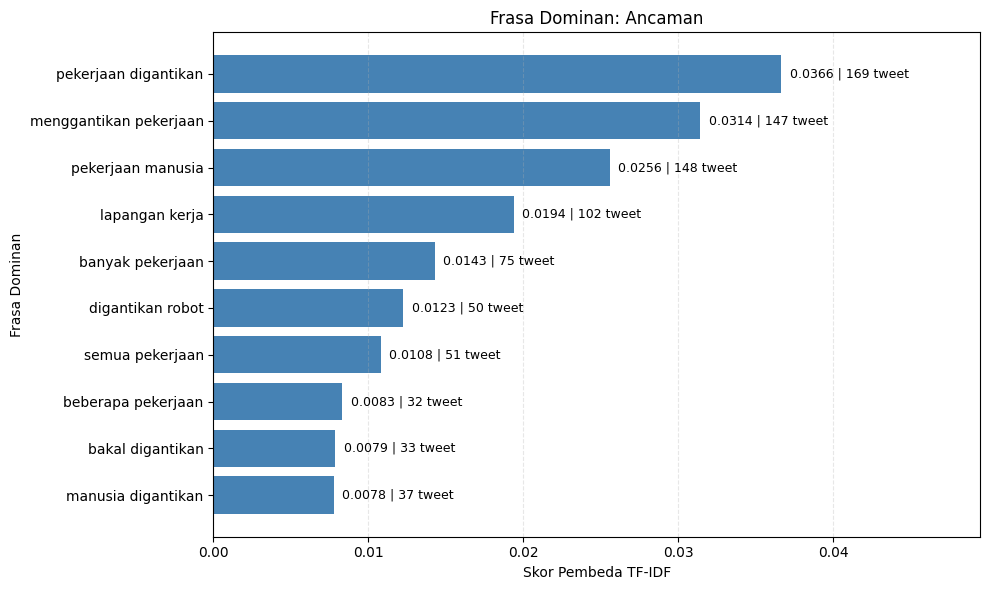

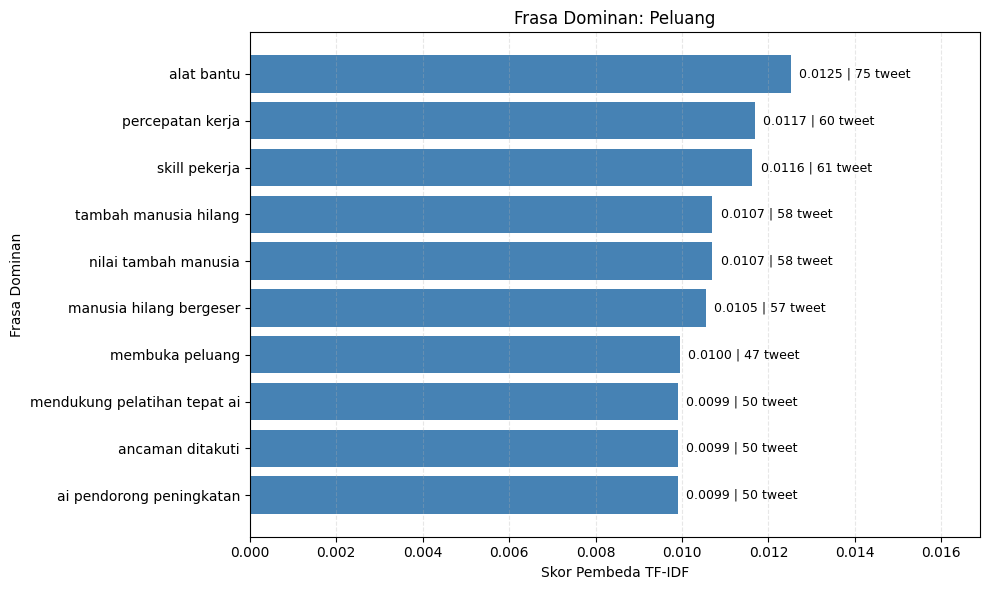

In [41]:
# Visualisasi 10 frasa dominan pada tiap kategori sentimen.
# Dibuat terpisah per kategori agar label lebih mudah dibaca.

if top_phrases_df.empty:
    print('Tidak ada frasa dominan yang dapat divisualisasikan.')
else:
    for label in label_order_phrase:
        plot_data = (
            top_phrases_df[top_phrases_df['label'] == label]
            .head(10)
            .sort_values('skor_pembeda')
        )

        if plot_data.empty:
            continue

        fig, ax = plt.subplots(figsize=(10, 6))
        bars = ax.barh(
            plot_data['frasa_dominan'],
            plot_data['skor_pembeda'],
            color='steelblue'
        )

        max_value = plot_data['skor_pembeda'].max()
        offset = max_value * 0.015 if max_value > 0 else 0.001
        for bar, value, count in zip(
            bars,
            plot_data['skor_pembeda'],
            plot_data['jumlah_tweet']
        ):
            ax.text(
                value + offset,
                bar.get_y() + bar.get_height() / 2,
                f'{value:.4f} | {count} tweet',
                va='center',
                fontsize=9
            )

        ax.set_title(f'Frasa Dominan: {label.capitalize()}')
        ax.set_xlabel('Skor Pembeda TF-IDF')
        ax.set_ylabel('Frasa Dominan')
        ax.grid(axis='x', linestyle='--', alpha=0.3)
        ax.set_xlim(0, max_value * 1.35 if max_value > 0 else 1)
        plt.tight_layout()
        plt.show()

### 4.17.2 Interpretasi Frasa Dominan

Berdasarkan hasil analisis frasa dominan, kategori `ancaman` dapat dibahas melalui frasa yang berkaitan dengan penggantian pekerjaan oleh AI, otomatisasi, serta kekhawatiran terhadap pekerjaan manusia. Frasa seperti `digantikan ai`, `pekerjaan digantikan`, dan `menggantikan pekerjaan` menunjukkan bahwa sebagian percakapan publik menyoroti risiko AI terhadap keberlangsungan pekerjaan.

Pada kategori `peluang`, frasa dominan cenderung berkaitan dengan AI sebagai alat bantu, peningkatan produktivitas, dan dukungan terhadap pekerjaan manusia. Frasa seperti `membantu pekerjaan`, `ai membantu`, dan `alat bantu` menunjukkan bahwa sebagian publik melihat AI sebagai teknologi yang dapat mendukung pekerjaan, bukan semata-mata menggantikan manusia.

Karena skenario modeling akhir dibuat biner, kategori `netral` tidak dianalisis sebagai kelas model. Data netral dikeluarkan agar evaluasi dan pembahasan frasa dominan lebih fokus pada perbedaan antara narasi ancaman dan narasi peluang.

### 4.17.3 Ringkasan Pembahasan Model

Hasil evaluasi pada skenario biner menunjukkan kemampuan model dalam membedakan narasi `ancaman` dan `peluang` setelah data `netral` dikeluarkan. Baseline TF-IDF + SVM tetap penting digunakan sebagai pembanding karena memberikan gambaran performa metode machine learning klasik.

Ketidakseimbangan data ditangani melalui stratified split, penggunaan class weight pada model, dan pembacaan metrik macro average serta weighted average pada classification report. Dengan demikian, interpretasi hasil tidak hanya bergantung pada accuracy, tetapi juga memperhatikan performa tiap kelas.